## 1. Environment, profile and configuration

In [ ]:
# ============================================================================
# 1. ENVIRONMENT, PROFILE AND CONFIGURATION
# ============================================================================
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import os, sys, json, math, time, glob, gc, re, io, random, pickle, hashlib, platform, subprocess, warnings, textwrap
from pathlib import Path
from collections import OrderedDict, defaultdict
from datetime import datetime, timezone
os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1"); os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

# ---- Choose ONE profile -----------------------------------------------------
#   "smoke"     : synthetic NHANES-like data + tiny random stand-in models. No downloads,
#                 no GPU. Verifies that the whole pipeline/figures/tables run (~3-6 min).
#   "quick"     : real NHANES + real models, heavily reduced sizes. Verifies downloads, model
#                 loading and VRAM headroom on your machine (~30-60 min).
#   "laptop8gb" : FULL study sized for RTX 4070 8 GB / 32 GB RAM (recommended, ~6-12 h).
#   "colab_t4"  : FULL study sized for free Colab T4 (16 GB VRAM, ~12 GB RAM), reduced draws.
# Optional access tokens: read from the environment (never hard-code them in this file).
# HF_TOKEN     - Hugging Face token, only needed for gated models.
# TABPFN_TOKEN - free TabPFN licence token from https://ux.priorlabs.ai (needed for the TabPFN arm).
PROFILE = os.environ.get("CKD_PROFILE", "laptop8gb")   # profile used for the paper; use "smoke" for the 3-6 min synthetic pipeline test.
# -----------------------------------------------------------------------------

IN_COLAB = "google.colab" in sys.modules or os.path.exists("/content")
# ---- Where everything lives: the folder that contains this notebook (override with env var CKD_PROJECT_DIR) ----------
PROJECT_DIR = Path(os.environ.get("CKD_PROJECT_DIR", "."))
if IN_COLAB:
    ROOT = Path("/content/ckd_system_one")
else:
    ROOT = PROJECT_DIR.resolve()
OUT = ROOT / f"outputs_{PROFILE}"
DIRS = {k: OUT / k for k in ["figures", "tables", "cache", "logs", "preds", "data"]}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)
DATA_RAW = ROOT / "nhanes_raw"          # shared across profiles (downloaded once)
DATA_RAW.mkdir(parents=True, exist_ok=True)

def keep_awake():
    """Windows: ask the OS not to go to sleep while this kernel is running (a many-hour job). No-op elsewhere.
    (Closing the lid or a forced update-restart can still stop it - that is exactly what the checkpoints are for.)"""
    try:
        if platform.system() == "Windows":
            import ctypes
            ctypes.windll.kernel32.SetThreadExecutionState(0x80000000 | 0x00000001)   # ES_CONTINUOUS | ES_SYSTEM_REQUIRED
            return True
    except Exception:
        pass
    return False
KEEP_AWAKE = keep_awake()

def _pip(*pkgs):
    """Install packages that are missing (import-name -> pip-name pairs)."""
    missing = []
    for imp, pipname in pkgs:
        try:
            __import__(imp)
        except Exception:
            missing.append(pipname)
    if missing:
        print("pip installing:", missing)
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

_pip(("numpy", "numpy"), ("pandas", "pandas"), ("scipy", "scipy"), ("sklearn", "scikit-learn"),
     ("matplotlib", "matplotlib"), ("xgboost", "xgboost"), ("pyarrow", "pyarrow"),
     ("tqdm", "tqdm"), ("requests", "requests"), ("statsmodels", "statsmodels"))

import numpy as np, pandas as pd, scipy
from scipy import stats
import matplotlib
matplotlib.use("Agg") if os.environ.get("CKD_HEADLESS") else None
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

try:
    import torch
    HAS_TORCH = True
except Exception:
    HAS_TORCH = False
if PROFILE != "smoke" and not HAS_TORCH:
    raise RuntimeError("PyTorch is required for this profile. Install it first (see the README).")
if HAS_TORCH:
    _pip(("transformers", "transformers"), ("safetensors", "safetensors"), ("huggingface_hub", "huggingface_hub"),
         ("peft", "peft"), ("accelerate", "accelerate"))
    _pip(("laya", "laya"))
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
else:
    DEVICE = "cpu"
if PROFILE not in ("smoke",) and DEVICE != "cuda":
    warnings.warn("No CUDA GPU detected: the real profiles will be extremely slow on CPU.")

# ---------------- Study constants (pre-registered; do not tune after seeing results) -------------
PRIMARY_SEED = 20261002
EQUIV_MARGIN_BRIER = 0.005     # H1 practical-equivalence margin on Brier score
MONO_EPS = 0.01                # tolerance (probability units) for a monotonicity violation
ALPHA = 0.05
HYPOTHESES = OrderedDict([
    ("H1", "After recalibration with >=64 labels, proper-score-trained and cross-entropy-trained System One heads reach equivalent Brier scores (|dBrier| < 0.005); any advantage is confined to <=32 labels."),
    ("H2", "Text-serialized decision models violate clinical monotonicity and flip under formatting/unit restatements more often than logistic regression / TabPFN; clinically binned inputs reduce this."),
    ("H3", "TabPFN matches or beats every System One / LLM arm on AUROC at >=16 labels (null-favouring)."),
    ("H4", "Calibration drift under temporal shift is larger for zero-shot arms than adapted arms, and <=64 target-period labels recover most of it."),
])

# ---------------- Profile-dependent sizes ---------------------------------------------------------
P = dict(
    smoke=dict(K_LIST=[8, 16, 32], K_ZS=[8, 16, 32], N_DRAWS_CHEAP=3, N_DRAWS_FT=2, N_DRAWS_ZS=3,
               N_TEST_CAP=300, N_POOL_ZS=400, N_RECAL_POOL=200, BOOT_B=60, K_MECH=[16], K_REL=32, K_SHIFT=16,
               N_MONO=12, N_FMT=24, N_MISS=60, N_IMPL=12, N_REPR=40, MISS_RATES=[0.0, 0.4, 0.8],
               FT_EPOCHS={8: 3, 16: 3, 32: 2}, FT_BS=8, RUN_ICL=False, ICL_K=[4], N_ICL_EVAL=40, N_ICL_DRAWS=1,
               LLM_BS=8, LAYA_BS=16, SYNTH_N=1800),
    quick=dict(K_LIST=[16, 64], K_ZS=[16, 64], N_DRAWS_CHEAP=4, N_DRAWS_FT=2, N_DRAWS_ZS=4,
               N_TEST_CAP=600, N_POOL_ZS=800, N_RECAL_POOL=400, BOOT_B=100, K_MECH=[64], K_REL=64, K_SHIFT=64,
               N_MONO=40, N_FMT=80, N_MISS=200, N_IMPL=40, N_REPR=120, MISS_RATES=[0.0, 0.4, 0.8],
               FT_EPOCHS={16: 20, 64: 12}, FT_BS=16, RUN_ICL=False, ICL_K=[8], N_ICL_EVAL=100, N_ICL_DRAWS=1,
               LLM_BS=8, LAYA_BS=32, SYNTH_N=0),
    laptop8gb=dict(K_LIST=[8, 16, 32, 64, 128, 256], K_ZS=[8, 16, 32, 64, 128, 256], N_DRAWS_CHEAP=30, N_DRAWS_FT=10,
                   N_DRAWS_ZS=30, N_TEST_CAP=2000, N_POOL_ZS=3000, N_RECAL_POOL=1000, BOOT_B=500,
                   K_MECH=[16, 64, 256], K_REL=256, K_SHIFT=64, N_MONO=200, N_FMT=400, N_MISS=1000, N_IMPL=200,
                   N_REPR=600, MISS_RATES=[0.0, 0.2, 0.4, 0.6, 0.8],
                   FT_EPOCHS={8: 30, 16: 25, 32: 20, 64: 15, 128: 10, 256: 8}, FT_BS=16, RUN_ICL=True, ICL_K=[4, 16],
                   N_ICL_EVAL=800, N_ICL_DRAWS=3, LLM_BS=8, LAYA_BS=32, SYNTH_N=0),
    colab_t4=dict(K_LIST=[8, 16, 32, 64, 128, 256], K_ZS=[8, 16, 32, 64, 128, 256], N_DRAWS_CHEAP=20, N_DRAWS_FT=6,
                  N_DRAWS_ZS=20, N_TEST_CAP=1500, N_POOL_ZS=2500, N_RECAL_POOL=800, BOOT_B=300,
                  K_MECH=[16, 64, 256], K_REL=256, K_SHIFT=64, N_MONO=150, N_FMT=300, N_MISS=800, N_IMPL=150,
                  N_REPR=450, MISS_RATES=[0.0, 0.2, 0.4, 0.6, 0.8],
                  FT_EPOCHS={8: 30, 16: 25, 32: 20, 64: 15, 128: 10, 256: 8}, FT_BS=16, RUN_ICL=False, ICL_K=[4, 16],
                  N_ICL_EVAL=500, N_ICL_DRAWS=2, LLM_BS=16, LAYA_BS=48, SYNTH_N=0),
)[PROFILE]
CFG = dict(PROFILE=PROFILE, **P)
if os.environ.get("CKD_FORCE_ICL") == "1": CFG["RUN_ICL"] = True      # testing hook

# Model identifiers (all open weights). The first loadable candidate is used.
CFG["LLM_CANDIDATES"] = ["Qwen/Qwen3-4B-Instruct-2507"]
CFG["LAYA_ID"] = "convaiinnovations/laya"
CFG["LAYA_ADAPT"] = "lora"          # "lora" (8 GB friendly) or "full" (needs ~16 GB + 8-bit Adam)
CFG["LORA_R"] = 16
CFG["RUN_PLAIN_INIT_ABLATION"] = False   # optional: ModernBERT-large init instead of Laya init (extra ~40 runs)
CFG["RUN_TABPFN"] = PROFILE != "smoke"
CFG["RUN_LLM"] = True
CFG["RUN_LAYA"] = True
CFG["FORCE_RERUN"] = False
CFG["RUN_ICL"] = False # True = ignore caches
CFG["N_DRAWS_FT"] = 5
CFG["HF_TOKEN"] = os.environ.get("HF_TOKEN") or None
if IN_COLAB:  
    try:
        from google.colab import userdata
        for k in ("HF_TOKEN", "TABPFN_TOKEN"):
            try:
                v = userdata.get(k)
                if v: os.environ[k] = v
            except Exception:
                pass
        CFG["HF_TOKEN"] = os.environ.get("HF_TOKEN")
    except Exception:
        pass

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    if HAS_TORCH:
        torch.manual_seed(seed)
        if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
set_seed(PRIMARY_SEED)
RNG = np.random.default_rng(PRIMARY_SEED)

T0 = time.time()
def log(*a):
    msg = f"[{(time.time()-T0)/60:6.1f} min] " + " ".join(str(x) for x in a)
    print(msg, flush=True)
    with open(DIRS["logs"] / "run.log", "a", encoding="utf-8") as f: f.write(datetime.now().strftime("%Y-%m-%d %H:%M:%S ") + msg + "\n")

log("PROFILE:", PROFILE, "| device:", DEVICE, "| colab:", IN_COLAB)
if DEVICE == "cuda":
    log("GPU:", torch.cuda.get_device_name(0), "| VRAM GB:", round(torch.cuda.get_device_properties(0).total_memory/1e9, 1))
log("Config:", json.dumps({k: v for k, v in CFG.items() if k != "HF_TOKEN"}, default=str)[:900])
log(f"project folder: {ROOT}")
log(f"RESUME CHECK: {len(list(DIRS['preds'].glob('*.npz')))} finished prediction runs and {len(list(DATA_RAW.glob('*.xpt')))} NHANES files already on disk -> they are reused; only missing work is computed. keep-awake: {'on' if KEEP_AWAKE else 'n/a'}")

W1004 22:10:27.532000 8324 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


[   0.0 min] PROFILE: laptop8gb | device: cuda | colab: False
[   0.0 min] GPU: NVIDIA GeForce RTX 4070 Laptop GPU | VRAM GB: 8.6
[   0.0 min] Config: {"PROFILE": "laptop8gb", "K_LIST": [8, 16, 32, 64, 128, 256], "K_ZS": [8, 16, 32, 64, 128, 256], "N_DRAWS_CHEAP": 30, "N_DRAWS_FT": 5, "N_DRAWS_ZS": 30, "N_TEST_CAP": 2000, "N_POOL_ZS": 3000, "N_RECAL_POOL": 1000, "BOOT_B": 500, "K_MECH": [16, 64, 256], "K_REL": 256, "K_SHIFT": 64, "N_MONO": 200, "N_FMT": 400, "N_MISS": 1000, "N_IMPL": 200, "N_REPR": 600, "MISS_RATES": [0.0, 0.2, 0.4, 0.6, 0.8], "FT_EPOCHS": {"8": 30, "16": 25, "32": 20, "64": 15, "128": 10, "256": 8}, "FT_BS": 16, "RUN_ICL": false, "ICL_K": [4, 16], "N_ICL_EVAL": 800, "N_ICL_DRAWS": 3, "LLM_BS": 8, "LAYA_BS": 32, "SYNTH_N": 0, "LLM_CANDIDATES": ["Qwen/Qwen3-4B-Instruct-2507"], "LAYA_ID": "convaiinnovations/laya", "LAYA_ADAPT": "lora", "LORA_R": 16, "RUN_PLAIN_INIT_ABLATION": false, "RUN_TABPFN": true, "RUN_LLM": true, "RUN_LAYA": true, "FORCE_RERUN": false}
[   0.0 min]

## 2. Utilities: metrics, calibration, recalibration, bootstrap statistics
*Calibration slope/intercept and Brier score are primary (ECE is secondary because it is unstable at small n). Paired bootstraps, Holm correction and a TOST-style equivalence check implement the pre-registered analysis plan.*

In [2]:
# ============================================================================
# 2. UTILITIES: caching, metrics, calibration, recalibration, bootstrap statistics
# ============================================================================
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, log_loss
from sklearn.linear_model import LogisticRegression
from scipy.special import expit, logit
from scipy.stats import rankdata
from scipy.optimize import minimize_scalar

EPS = 1e-6
def clip_p(p): return np.clip(np.asarray(p, dtype=np.float64), EPS, 1 - EPS)
def to_logit(p): return logit(clip_p(p))

def cache_path(name): return DIRS["cache"] / name

def _replace_retry(tmp, dst, tries=20):
    """os.replace with retries (Windows: antivirus / indexer / sync clients can hold a file for a moment)."""
    for i in range(tries):
        try:
            os.replace(tmp, dst); return
        except PermissionError:
            if i == tries - 1: raise
            time.sleep(0.25 * (i + 1))

def atomic_write(path, writer, mode="wb"):
    """Checkpoint writer: write to <file>.tmp, flush + fsync, then rename. A shutdown/crash can never leave a half-written
    checkpoint behind: the previous file (or nothing) stays until the new one is complete."""
    path = Path(path); tmp = path.with_name(path.name + ".tmp")
    with open(tmp, mode) as f:
        writer(f); f.flush()
        try: os.fsync(f.fileno())
        except OSError: pass
    _replace_retry(tmp, path)

for _t in ROOT.rglob("*.tmp"):            # leftovers of a write that was interrupted by a shutdown
    try: _t.unlink()
    except Exception: pass

def cached(name, fn, force=None):
    """Compute-once helper (pickle, atomic). Set CFG['FORCE_RERUN']=True to recompute."""
    p = cache_path(name)
    force = CFG["FORCE_RERUN"] if force is None else force
    if p.exists() and not force:
        try:
            with open(p, "rb") as f: return pickle.load(f)
        except Exception as e:
            log(f"  [ckpt] cache {name} unreadable ({str(e)[:60]}) -> recomputing")
    obj = fn()
    atomic_write(p, lambda f: pickle.dump(obj, f))
    return obj

# ------------------------------------------------------------------ discrimination / calibration metrics
def fast_auc(y, p):
    y = np.asarray(y); p = np.asarray(p)
    n1 = y.sum(); n0 = len(y) - n1
    if n1 == 0 or n0 == 0: return np.nan
    r = rankdata(p)
    return (r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)

def fast_auc_matrix(y, P):
    """AUROC of each row of P (R x n) against y (n,)"""
    y = np.asarray(y); n1 = y.sum(); n0 = len(y) - n1
    if n1 == 0 or n0 == 0: return np.full(P.shape[0], np.nan)
    R = rankdata(P, axis=1)
    return (R[:, y == 1].sum(1) - n1 * (n1 + 1) / 2) / (n1 * n0)

def ece_adaptive(y, p, n_bins=10):
    """Expected calibration error with equal-mass bins (more stable than equal-width bins at low prevalence)."""
    y = np.asarray(y, float); p = clip_p(p)
    order = np.argsort(p); y = y[order]; p = p[order]
    bins = np.array_split(np.arange(len(p)), min(n_bins, max(1, len(p) // 5)))
    return float(sum(len(b) / len(p) * abs(y[b].mean() - p[b].mean()) for b in bins if len(b)))

def cal_slope_intercept(y, p):
    """Calibration slope b and intercept a from logistic regression y ~ a + b*logit(p)."""
    y = np.asarray(y); z = to_logit(p).reshape(-1, 1)
    if y.sum() == 0 or y.sum() == len(y) or np.std(z) < 1e-9: return np.nan, np.nan
    m = LogisticRegression(penalty=None, solver="lbfgs", max_iter=500).fit(z, y)
    return float(m.coef_[0, 0]), float(m.intercept_[0])

def citl(y, p):
    """Calibration-in-the-large: intercept a with slope fixed at 1 (offset model). 0 = perfectly calibrated on average."""
    y = np.asarray(y, float); z = to_logit(p)
    f = lambda a: abs(np.mean(expit(a + z)) - y.mean())
    return float(minimize_scalar(f, bounds=(-8, 8), method="bounded").x)

def net_benefit(y, p, thresholds):
    y = np.asarray(y); p = np.asarray(p); n = len(y)
    out = []
    for t in thresholds:
        pred = p >= t
        tp = np.sum(pred & (y == 1)); fp = np.sum(pred & (y == 0))
        out.append(tp / n - fp / n * (t / (1 - t)))
    return np.array(out)

METRICS = ["auroc", "auprc", "brier", "logloss", "ece", "slope", "intercept", "citl"]
def all_metrics(y, p):
    y = np.asarray(y).astype(int); p = clip_p(p)
    s, a = cal_slope_intercept(y, p)
    try: ll = log_loss(y, p, labels=[0, 1])
    except Exception: ll = np.nan
    return dict(auroc=fast_auc(y, p), auprc=average_precision_score(y, p) if 0 < y.sum() < len(y) else np.nan,
                brier=float(np.mean((p - y) ** 2)), logloss=float(ll), ece=ece_adaptive(y, p),
                slope=s, intercept=a, citl=citl(y, p))

# ------------------------------------------------------------------ recalibration (K-label adaptation of zero-shot arms)
def fit_platt(s, y):
    """2-parameter logistic recalibration of a raw logit score s. Returns (a, b) with p = expit(a + b*s)."""
    s = np.asarray(s, float).reshape(-1, 1); y = np.asarray(y)
    if len(np.unique(y)) < 2: return 0.0, 1.0
    m = LogisticRegression(penalty="l2", C=10.0, solver="lbfgs", max_iter=1000).fit(s, y)
    return float(m.intercept_[0]), float(m.coef_[0, 0])

def fit_temperature(s, y):
    """1-parameter temperature scaling p = expit(s / T), T fitted by maximum likelihood."""
    s = np.asarray(s, float); y = np.asarray(y, float)
    def nll(logT):
        z = s / np.exp(logT); pz = np.clip(expit(z), 1e-9, 1 - 1e-9)
        return -np.mean(y * np.log(pz) + (1 - y) * np.log(1 - pz))
    r = minimize_scalar(nll, bounds=(-3, 3), method="bounded")
    return float(np.exp(r.x))

def apply_platt(s, ab): return expit(ab[0] + ab[1] * np.asarray(s, float))
def apply_temp(s, T): return expit(np.asarray(s, float) / T)

# ------------------------------------------------------------------ label-budget sampling
def draw_labeled(y_pool, K, seed, min_per_class=2):
    """Random subset of size K at natural prevalence; redraws until both classes appear >= min_per_class times
    (the minimum any supervised learner needs). Returns indices into the pool."""
    rng = np.random.default_rng(seed); n = len(y_pool)
    for _ in range(10000):
        idx = rng.choice(n, size=K, replace=False)
        yy = y_pool[idx]
        if yy.sum() >= min_per_class and (K - yy.sum()) >= min_per_class: return np.sort(idx)
    raise RuntimeError("could not draw a label budget with both classes")

# ------------------------------------------------------------------ statistics
def percentile_ci(x, level=0.95):
    x = np.asarray(x, float); x = x[~np.isnan(x)]
    if len(x) == 0: return (np.nan, np.nan, np.nan)
    lo, hi = np.percentile(x, [(1 - level) / 2 * 100, (1 + level) / 2 * 100]) if len(x) > 1 else (x[0], x[0])
    return (float(np.mean(x)), float(lo), float(hi))

def holm(pvals):
    """Holm-Bonferroni adjusted p-values."""
    p = np.asarray(pvals, float); m = len(p); order = np.argsort(p); adj = np.empty(m)
    run = 0.0
    for rank, i in enumerate(order):
        run = max(run, (m - rank) * p[i]); adj[i] = min(1.0, run)
    return adj

def paired_boot_diff(y, PA, PB, metric="brier", B=300, seed=0):
    """Paired bootstrap of the difference (A - B) in a metric, averaged over D training draws.
    PA, PB: (D x n) predictions on the same test rows. Test rows are resampled jointly for A and B.
    Returns (mean_diff, lo, hi, two-sided p)."""
    rng = np.random.default_rng(seed); y = np.asarray(y); n = len(y); diffs = np.empty(B)
    for b in range(B):
        idx = rng.integers(0, n, n); yb = y[idx]
        if metric == "brier":
            da = ((PA[:, idx] - yb) ** 2).mean(1); db = ((PB[:, idx] - yb) ** 2).mean(1)
        elif metric == "auroc":
            da = fast_auc_matrix(yb, PA[:, idx]); db = fast_auc_matrix(yb, PB[:, idx])
        elif metric == "ece":
            da = np.array([ece_adaptive(yb, r[idx]) for r in PA]); db = np.array([ece_adaptive(yb, r[idx]) for r in PB])
        else: raise ValueError(metric)
        diffs[b] = np.nanmean(da - db)
    lo, hi = np.percentile(diffs, [2.5, 97.5]); mean = float(np.mean(diffs))
    p = 2 * min((diffs <= 0).mean(), (diffs >= 0).mean()); p = max(p, 1.0 / B)
    return mean, float(lo), float(hi), float(p)

def tost_equivalent(lo90, hi90, margin): return (lo90 > -margin) and (hi90 < margin)

# ------------------------------------------------------------------ misc
def sizeof_fmt(n): return f"{n/1e9:.2f} GB" if n > 1e9 else f"{n/1e6:.1f} MB"
class Timer:
    def __init__(self): self.t = {}
    def __call__(self, name):
        class _C:
            def __enter__(s2): s2.t0 = time.time(); return s2
            def __exit__(s2, *a): self.t[name] = self.t.get(name, 0.0) + time.time() - s2.t0
        return _C()
TIMER = Timer()
def gpu_mem_peak():
    return torch.cuda.max_memory_allocated() / 1e9 if (HAS_TORCH and torch.cuda.is_available()) else 0.0

## 3. Data: NHANES 2011–2023 (public, de-identified)
*Development = 2011–2016. Temporal test sets = 2017–Mar 2020 and 2021–2023. Inputs are 13 low-lab screening variables; serum creatinine, eGFR, UACR and any kidney-function proxy (e.g. BUN) are excluded to prevent label leakage. Race/ethnicity is not a model input.*

In [3]:
# ============================================================================
# 3. DATA: NHANES download (public, de-identified) -> adult CKD-range label -> temporal splits
# ============================================================================
import requests

CYCLES = OrderedDict([("2011-2012", dict(suffix="_G", year=2011, prefix="")),
                      ("2013-2014", dict(suffix="_H", year=2013, prefix="")),
                      ("2015-2016", dict(suffix="_I", year=2015, prefix="")),
                      ("2017-2020", dict(suffix="", year=2017, prefix="P_")),   # pre-pandemic combined cycle
                      ("2021-2023", dict(suffix="_L", year=2021, prefix=""))])
DEV_CYCLES, T1_CYCLES, T2_CYCLES = ["2011-2012", "2013-2014", "2015-2016"], ["2017-2020"], ["2021-2023"]
FEATURES = ["age", "sex_female", "bmi", "waist", "sbp", "dbp", "hba1c", "diabetes", "htn", "chf", "chd", "stroke", "smoker"]
CONTINUOUS = ["age", "bmi", "waist", "sbp", "dbp", "hba1c"]
BINARY = ["sex_female", "diabetes", "htn", "chf", "chd", "stroke", "smoker"]
# Variables that define or proxy the label are NEVER allowed as inputs (label-leakage guard).
LEAK_BLACKLIST = {"y", "egfr", "acr", "scr", "creatinine", "urdact", "lbxscr", "bun", "lbxsbu", "uric", "cystatin"}
assert not (set(FEATURES) & LEAK_BLACKLIST), "label-leakage guard failed"
UA = {"User-Agent": "Mozilla/5.0 (research notebook; NHANES public-use files)"}

LEGACY_FOLDER = {"2011-2012": "2011-2012", "2013-2014": "2013-2014", "2015-2016": "2015-2016", "2017-2020": "2017-2018", "2021-2023": "2021-2023"}
def nh_urls(name, year, cyc):
    return [f"https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/{year}/DataFiles/{name}.xpt",
            f"https://wwwn.cdc.gov/Nchs/Nhanes/{LEGACY_FOLDER[cyc]}/{name}.XPT",
            f"https://wwwn.cdc.gov/Nchs/Nhanes/{LEGACY_FOLDER[cyc]}/{name}.xpt"]

def download_xpt(name, year, cyc, retries=2):
    path = DATA_RAW / f"{name}.xpt"
    if path.exists() and path.stat().st_size > 2000: return path       # already on disk (previous run, or placed manually) -> reuse, no download
    last = None
    for url in nh_urls(name, year, cyc):
        for k in range(retries):
            try:
                r = requests.get(url, headers=UA, timeout=180)
                if r.status_code == 200 and r.content[:6] == b"HEADER":
                    atomic_write(path, lambda f: f.write(r.content)); log(f"  [data] downloaded {path.name} ({len(r.content) / 1e6:.1f} MB)"); return path
                last = f"HTTP {r.status_code}, {len(r.content)} bytes ({url})"
            except Exception as e:
                last = repr(e)
            time.sleep(2 * (k + 1))
    raise FileNotFoundError(f"Could not download {name} ({last}). Download it manually from the NHANES data page "
                            f"(https://wwwn.cdc.gov/nchs/nhanes/search/datapage.aspx) and place {name}.xpt in {DATA_RAW}/")

def read_xpt(name, year, cyc, required=True):
    try:
        p = download_xpt(name, year, cyc)
        try:
            df = pd.read_sas(p, format="xport")
        except Exception:
            log(f"  [data] {p.name} on disk is unreadable -> deleting it and downloading again"); p.unlink(missing_ok=True)
            p = download_xpt(name, year, cyc); df = pd.read_sas(p, format="xport")
        df["SEQN"] = df["SEQN"].astype(int)
        return df
    except Exception as e:
        if required: raise
        log(f"  [warn] optional file {name} unavailable ({str(e)[:90]}); its columns will be missing for this cycle")
        return None

def yn(s):  # NHANES 1=yes 2=no, anything else -> missing
    return s.map({1: 1.0, 2: 0.0})

def ckd_epi_2021(scr, age, female):
    kappa = np.where(female == 1, 0.7, 0.9); alpha = np.where(female == 1, -0.241, -0.302)
    r = scr / kappa
    return 142.0 * np.minimum(r, 1) ** alpha * np.maximum(r, 1) ** (-1.200) * 0.9938 ** age * np.where(female == 1, 1.012, 1.0)

def build_cycle(cyc):
    c = CYCLES[cyc]; fn = lambda base: f"{c['prefix']}{base}{c['suffix']}"; yr = c["year"]
    demo = read_xpt(fn("DEMO"), yr, cyc)[["SEQN", "RIAGENDR", "RIDAGEYR", "RIDRETH3"]]
    bio = read_xpt(fn("BIOPRO"), yr, cyc)[["SEQN", "LBXSCR"]]
    alb = read_xpt(fn("ALB_CR"), yr, cyc)[["SEQN", "URDACT"]]
    df = demo.merge(bio, on="SEQN", how="inner").merge(alb, on="SEQN", how="left")
    bmx = read_xpt(fn("BMX"), yr, cyc, required=False)
    df = df.merge(bmx[["SEQN"] + [x for x in ["BMXBMI", "BMXWAIST"] if x in bmx]], on="SEQN", how="left") if bmx is not None else df
    bp_base = "BPXO" if c["prefix"] == "P_" or cyc == "2021-2023" else "BPX"
    bp = read_xpt(fn(bp_base), yr, cyc, required=False)
    if bp is not None:
        sy = [x for x in bp.columns if re.fullmatch(r"BPXO?SY\d", x)]; di = [x for x in bp.columns if re.fullmatch(r"BPXO?DI\d", x)]
        t = bp[["SEQN"]].copy()
        t["sbp"] = bp[sy].where(bp[sy] > 0).mean(axis=1); t["dbp"] = bp[di].where(bp[di] > 0).mean(axis=1)
        df = df.merge(t, on="SEQN", how="left")
    for base, cols in [("GHB", ["LBXGH"]), ("DIQ", ["DIQ010"]), ("BPQ", ["BPQ020"]),
                       ("MCQ", ["MCQ160B", "MCQ160C", "MCQ160F"]), ("SMQ", ["SMQ020"])]:
        t = read_xpt(fn(base), yr, cyc, required=False)
        if t is not None:
            df = df.merge(t[["SEQN"] + [x for x in cols if x in t]], on="SEQN", how="left")
    for col in ["BMXBMI", "BMXWAIST", "sbp", "dbp", "LBXGH", "DIQ010", "BPQ020", "MCQ160B", "MCQ160C", "MCQ160F", "SMQ020", "RIDRETH3"]:
        if col not in df: df[col] = np.nan
    out = pd.DataFrame({
        "uid": cyc + "_" + df["SEQN"].astype(str), "cycle": cyc,
        "age": df["RIDAGEYR"].astype(float), "sex_female": (df["RIAGENDR"] == 2).astype(float),
        "bmi": df["BMXBMI"], "waist": df["BMXWAIST"], "sbp": df["sbp"], "dbp": df["dbp"], "hba1c": df["LBXGH"],
        "diabetes": df["DIQ010"].map({1: 1.0, 2: 0.0}), "htn": yn(df["BPQ020"]),
        "chf": yn(df["MCQ160B"]), "chd": yn(df["MCQ160C"]), "stroke": yn(df["MCQ160F"]), "smoker": yn(df["SMQ020"]),
        "race_eth": df["RIDRETH3"], "scr": df["LBXSCR"], "acr": df["URDACT"]})
    out = out[(out["age"] >= 18) & out["scr"].notna()].copy()
    out["egfr"] = ckd_epi_2021(out["scr"].values, out["age"].values, out["sex_female"].values)
    low = out["egfr"] < 60; alb_hi = out["acr"] >= 30
    out = out[low | out["acr"].notna()].copy()                        # label unknown if eGFR>=60 and UACR missing
    out["y"] = ((out["egfr"] < 60) | (out["acr"] >= 30)).astype(int)
    return out.reset_index(drop=True)

def synth_nhanes(n_total, seed=1):
    """Synthetic NHANES-like data used ONLY in the 'smoke' profile (never for results)."""
    rng = np.random.default_rng(seed); rows = []
    shifts = {"2011-2012": 0.0, "2013-2014": 0.0, "2015-2016": 0.05, "2017-2020": 0.35, "2021-2023": 0.6}
    for cyc, sh in shifts.items():
        n = n_total // len(shifts)
        age = np.clip(rng.normal(50, 17, n), 18, 85).round(); fem = rng.integers(0, 2, n).astype(float)
        bmi = np.clip(rng.lognormal(3.35, 0.2, n), 16, 60).round(1); waist = np.clip(bmi * 3.1 + rng.normal(0, 7, n), 60, 160).round(1)
        sbp = (108 + 0.45 * age + 0.25 * (bmi - 27) + rng.normal(0, 12, n) + (3 if cyc in ("2017-2020", "2021-2023") else 0)).round()
        dbp = np.clip(70 + 0.1 * (sbp - 120) + rng.normal(0, 8, n), 40, 120).round()
        diab = (rng.random(n) < expit(-4.2 + 0.04 * age + 0.06 * (bmi - 27))).astype(float)
        hba1c = np.clip(5.3 + 1.6 * diab + rng.normal(0, 0.5, n), 4.0, 14).round(1)
        htn = (rng.random(n) < expit(-4 + 0.04 * age + 0.03 * (sbp - 120))).astype(float)
        chf = (rng.random(n) < expit(-6 + 0.045 * age)).astype(float); chd = (rng.random(n) < expit(-5.6 + 0.045 * age)).astype(float)
        stroke = (rng.random(n) < expit(-5.8 + 0.04 * age)).astype(float); smoker = (rng.random(n) < 0.45).astype(float)
        lg = -5.2 + 0.045 * age + 0.016 * (sbp - 120) + 0.55 * diab + 0.35 * htn + 0.25 * (hba1c - 5.5) + 0.8 * chf + 0.3 * chd + 0.3 * stroke + 0.1 * fem + sh
        y = (rng.random(n) < expit(lg)).astype(int)
        d = pd.DataFrame(dict(uid=[f"{cyc}_{i}" for i in range(n)], cycle=cyc, age=age, sex_female=fem, bmi=bmi, waist=waist, sbp=sbp, dbp=dbp,
                              hba1c=hba1c, diabetes=diab, htn=htn, chf=chf, chd=chd, stroke=stroke, smoker=smoker,
                              race_eth=rng.integers(1, 7, n).astype(float), scr=np.nan, acr=np.nan, egfr=np.nan, y=y))
        for col in ["bmi", "waist", "sbp", "dbp", "hba1c"]: d.loc[rng.random(n) < 0.05, col] = np.nan
        for col in ["diabetes", "htn", "smoker", "chf", "chd", "stroke"]: d.loc[rng.random(n) < 0.03, col] = np.nan
        rows.append(d)
    return pd.concat(rows, ignore_index=True)

# ------------------------------------------------------------------ build the analysis table
def load_all():
    if PROFILE == "smoke":
        log("SMOKE profile: using SYNTHETIC data (never report results from this profile).")
        return synth_nhanes(CFG["SYNTH_N"])
    frames = []
    log(f"  NHANES raw files already on disk: {len(list(DATA_RAW.glob('*.xpt')))} (existing files are reused; only missing ones are downloaded)")
    for cyc in CYCLES:
        try:
            frames.append(build_cycle(cyc)); log(f"  cycle {cyc}: n={len(frames[-1])}, CKD-range prevalence={frames[-1]['y'].mean():.3f}")
        except Exception as e:
            log(f"  [ERROR] cycle {cyc} skipped: {str(e)[:200]}")
    if not frames: raise RuntimeError("No NHANES cycle could be loaded. Check internet access or place the .xpt files in " + str(DATA_RAW))
    return pd.concat(frames, ignore_index=True)

DF = cached(f"nhanes_{'synth' if PROFILE=='smoke' else 'real'}.pkl", load_all)
DF_ALL_BEFORE_CAP = DF.copy()
log(f"Analysis table: {len(DF)} adults across cycles {sorted(DF['cycle'].unique())}")

# ------------------------------------------------------------------ splits (by participant; every uid is unique -> patient-level split)
def stratified_split(df, fracs, seed):
    rng = np.random.default_rng(seed); names = list(fracs); out = {n: [] for n in names}
    for yv in (0, 1):
        idx = np.where(df["y"].values == yv)[0]; rng.shuffle(idx); cuts = (np.cumsum([fracs[n] for n in names]) * len(idx)).astype(int)
        start = 0
        for n, c in zip(names, cuts):
            out[n].append(idx[start:c]); start = c
    return {n: np.sort(np.concatenate(v)) for n, v in out.items()}

def cap(df_idx, n, seed):
    if n is None or len(df_idx) <= n: return df_idx
    rng = np.random.default_rng(seed); return np.sort(rng.choice(df_idx, n, replace=False))

dev = DF[DF["cycle"].isin(DEV_CYCLES)].reset_index(drop=True)
t1 = DF[DF["cycle"].isin(T1_CYCLES)].reset_index(drop=True)
t2 = DF[DF["cycle"].isin(T2_CYCLES)].reset_index(drop=True)
sp_dev = stratified_split(dev, dict(pool=0.45, val=0.15, int=0.40), PRIMARY_SEED)   # pool: label pool; val: recalibration labels; int: internal test
sp_t1 = stratified_split(t1, dict(T1pool=0.2, T1=0.8), PRIMARY_SEED + 1)
sp_t2 = stratified_split(t2, dict(T2pool=0.2, T2=0.8), PRIMARY_SEED + 2)

parts, names = [], []
def add(name, df_, idx, n_cap):
    idx = cap(idx, n_cap, PRIMARY_SEED + len(parts)); parts.append(df_.iloc[idx].copy().assign(split=name))
add("pool", dev, sp_dev["pool"], CFG["N_POOL_ZS"]); add("val", dev, sp_dev["val"], CFG["N_RECAL_POOL"])
add("int", dev, sp_dev["int"], CFG["N_TEST_CAP"])
add("T1pool", t1, sp_t1["T1pool"], CFG["N_RECAL_POOL"]); add("T1", t1, sp_t1["T1"], CFG["N_TEST_CAP"])
add("T2pool", t2, sp_t2["T2pool"], CFG["N_RECAL_POOL"]); add("T2", t2, sp_t2["T2"], CFG["N_TEST_CAP"])
ALL = pd.concat(parts, ignore_index=True)
Y = ALL["y"].values.astype(int)
IDX = {s: np.where(ALL["split"].values == s)[0] for s in ["pool", "val", "int", "T1pool", "T1", "T2pool", "T2"]}
PRED_SETS = ["val", "int", "T1pool", "T1", "T2pool", "T2"]
EVAL_SETS = ["int", "T1", "T2"]
PRED_IDX = np.concatenate([IDX[s] for s in PRED_SETS])          # rows predicted by trained arms
_off = np.cumsum([0] + [len(IDX[s]) for s in PRED_SETS]); SLICE = {s: slice(_off[i], _off[i + 1]) for i, s in enumerate(PRED_SETS)}
XALL = ALL[FEATURES].copy()
DEV_PREV = float(Y[IDX["pool"]].mean())
FEAT_STATS = {c: dict(p05=float(np.nanpercentile(XALL.loc[IDX["pool"], c], 5)), p95=float(np.nanpercentile(XALL.loc[IDX["pool"], c], 95)),
                      deciles=np.nanpercentile(XALL.loc[IDX["pool"], c], np.arange(10, 100, 10)).tolist()) for c in CONTINUOUS}
for s in IDX: log(f"  split {s:7s}: n={len(IDX[s]):6d}  prevalence={Y[IDX[s]].mean():.3f}")
assert all(len(set(ALL['uid'])) == len(ALL) for _ in [0]), "participant overlap between splits"

# ------------------------------------------------------------------ checkpoint safety: stale-cache guard
import shutil
def _design_signature():
    h = hashlib.sha256()
    h.update(json.dumps(dict(profile=PROFILE, seed=PRIMARY_SEED, n_pool=CFG["N_POOL_ZS"], n_recal=CFG["N_RECAL_POOL"], n_test=CFG["N_TEST_CAP"],
                             features=FEATURES, n=len(ALL)), sort_keys=True).encode())
    h.update("|".join(ALL["uid"].astype(str)).encode()); h.update("|".join(ALL["split"].astype(str)).encode()); h.update(Y.tobytes())
    return h.hexdigest()[:16]
SIG = _design_signature(); _sig_file = DIRS["logs"] / "design_signature.txt"
if _sig_file.exists() and _sig_file.read_text().strip() != SIG:
    _stale = ROOT / f"stale_{PROFILE}_{datetime.now():%Y%m%d_%H%M%S}"; _stale.mkdir(parents=True, exist_ok=True)
    log(f"[ckpt] data/splits/sizes changed since the cached runs were made -> moving the old runs to {_stale.name} (nothing is deleted)")
    for _p in list(DIRS["preds"].glob("*")): shutil.move(str(_p), str(_stale / _p.name))
    for _p in list(DIRS["cache"].glob("*")):
        if not _p.name.startswith("nhanes_"): shutil.move(str(_p), str(_stale / _p.name))
_sig_file.write_text(SIG)
log("design fingerprint:", SIG)


[   0.0 min] Analysis table: 29758 adults across cycles ['2011-2012', '2013-2014', '2015-2016', '2017-2020', '2021-2023']
[   0.0 min]   split pool   : n=  3000  prevalence=0.164
[   0.0 min]   split val    : n=  1000  prevalence=0.162
[   0.0 min]   split int    : n=  2000  prevalence=0.158
[   0.0 min]   split T1pool : n=  1000  prevalence=0.187
[   0.0 min]   split T1     : n=  2000  prevalence=0.189
[   0.0 min]   split T2pool : n=  1000  prevalence=0.173
[   0.0 min]   split T2     : n=  2000  prevalence=0.183
[   0.0 min] design fingerprint: 8622c7b81a4af43e


## 4. Text serialization and perturbation helpers
*All language-oriented arms see the same clinical state, rendered by a fixed template (raw numbers with units, clinically binned, or percentile rank).*

In [4]:
# ============================================================================
# 4. TEXT SERIALIZATION OF THE CLINICAL STATE (for language / System One arms) + perturbation helpers
# ============================================================================
QUESTION = ("Based on this adult's record, does the person most likely have chronic kidney disease, i.e. reduced kidney function "
            "(estimated GFR below 60 mL/min/1.73 m2) or albuminuria (urine albumin-to-creatinine ratio of at least 30 mg/g)?")
OPT_YES = "Yes: reduced kidney function or albuminuria is likely present."
OPT_NO = "No: kidney function is likely normal and albuminuria is unlikely."

def _bin(name, v, sex_female=None):
    if name == "age":   return "18-39 years" if v < 40 else "40-59 years" if v < 60 else "60-74 years" if v < 75 else "75 years or older"
    if name == "bmi":   return ("underweight (<18.5)" if v < 18.5 else "normal (18.5-24.9)" if v < 25 else "overweight (25-29.9)" if v < 30 else
                                "obesity class I (30-34.9)" if v < 35 else "obesity class II (35-39.9)" if v < 40 else "obesity class III (>=40)")
    if name == "waist":
        thr = 88 if sex_female == 1 else 102
        return f"elevated (>{thr} cm)" if v > thr else f"not elevated (<={thr} cm)"
    if name == "sbp":  return "normal (<120)" if v < 120 else "elevated (120-129)" if v < 130 else "stage 1 hypertension range (130-139)" if v < 140 else "stage 2 hypertension range (>=140)"
    if name == "dbp":  return "normal (<80)" if v < 80 else "stage 1 hypertension range (80-89)" if v < 90 else "stage 2 hypertension range (>=90)"
    if name == "hba1c": return "normal (<5.7%)" if v < 5.7 else "prediabetes range (5.7-6.4%)" if v < 6.5 else "diabetes range (>=6.5%)"
    raise KeyError(name)

LABELS = dict(age="Age", sex_female="Sex", bmi="Body mass index", waist="Waist circumference", sbp="Systolic blood pressure",
              dbp="Diastolic blood pressure", hba1c="Hemoglobin A1c", diabetes="Diagnosed diabetes", htn="Told by a doctor of high blood pressure",
              chf="History of congestive heart failure", chd="History of coronary heart disease", stroke="History of stroke",
              smoker="Smoked at least 100 cigarettes in lifetime")
SHORT = dict(age="age", sex_female="sex", bmi="BMI", waist="waist", sbp="SBP", dbp="DBP", hba1c="HbA1c", diabetes="diabetes", htn="hypertension",
             chf="heart failure", chd="coronary disease", stroke="stroke", smoker="smoker")

def _val(name, v, style, units, sex_female):
    """Return the value string for one field."""
    if name == "sex_female": return "female" if v == 1 else "male"
    if name in BINARY: return "yes" if v == 1 else "no"
    if style == "binned" and name in CONTINUOUS and name != "age" or (style == "binned" and name == "age"):
        return _bin(name, v, sex_female)
    if style == "rank" and name in CONTINUOUS:
        d = int(np.searchsorted(FEAT_STATS[name]["deciles"], v, side="right"))
        return f"{10 * d}-{10 * (d + 1)}th percentile of US adults"
    # raw numbers, with explicit units (optionally restated in alternative units)
    if name == "age": return f"{v:.0f} years"
    if name == "bmi": return f"{v:.1f} kg/m2"
    if name == "waist": return f"{v / 2.54:.1f} in" if units == "alt" else f"{v:.0f} cm"
    if name in ("sbp", "dbp"): return f"{v * 0.133322:.1f} kPa" if units == "alt" else f"{v:.0f} mmHg"
    if name == "hba1c": return f"{(v - 2.15) * 10.929:.0f} mmol/mol" if units == "alt" else f"{v:.1f} %"
    return f"{v}"

def serialize_row(row, style="raw", template="list", units="default", order="default", seed=0):
    sf = row.get("sex_female", np.nan)
    names = [n for n in FEATURES if not pd.isna(row[n])]
    if order == "reversed": names = names[::-1]
    elif order == "shuffled": names = list(np.random.default_rng(seed).permutation(names))
    parts = []
    for n in names:
        v = _val(n, float(row[n]), style, units, sf)
        if template == "list": parts.append(f"{LABELS[n]}: {v}")
        elif template == "compact": parts.append(f"{SHORT[n]} {v}")
        elif template == "sentence": parts.append(f"{LABELS[n]} is {v}.")
        else: raise ValueError(template)
    if not parts: return "No clinical information available."
    return {"list": "\n", "compact": "; ", "sentence": " "}[template].join(parts)

def serialize_df(X, **kw):
    cols = list(X.columns); vals = X.values
    return [serialize_row(dict(zip(cols, r)), **kw) for r in vals]

# ---------------- perturbation helpers (reliability suite) ----------------
def drop_features(X, rate, seed):
    rng = np.random.default_rng(seed); Xp = X.copy()
    mask = rng.random(Xp.shape) < rate
    Xp = Xp.mask(pd.DataFrame(mask, index=Xp.index, columns=Xp.columns)); return Xp

IMPLAUSIBLE = dict(age=250.0, bmi=150.0, waist=400.0, sbp=20.0, dbp=5.0, hba1c=40.0)
def sweep_grid(feature, n=6):
    s = FEAT_STATS[feature]; return np.linspace(s["p05"], s["p95"], n)

# monotonic direction expected clinically: risk should not DEcrease as these increase
MONO_FEATURES = [("age", "cont"), ("sbp", "cont"), ("hba1c", "cont"), ("diabetes", "bin"), ("htn", "bin")]

def build_mono_frames(X_base, rng_seed=0):
    """Return a list of (feature, case_id, grid_pos, X_row_frame) stacked as one DataFrame with metadata."""
    rows, meta = [], []
    for feat, kind in MONO_FEATURES:
        grid = sweep_grid(feat, 6) if kind == "cont" else np.array([0.0, 1.0])
        for ci in range(len(X_base)):
            for gi, g in enumerate(grid):
                r = X_base.iloc[ci].copy(); r[feat] = g; rows.append(r); meta.append((feat, ci, gi))
    Xs = pd.DataFrame(rows).reset_index(drop=True); M = pd.DataFrame(meta, columns=["feature", "case", "pos"])
    return Xs, M

def mono_violation_rate(p, M, eps=MONO_EPS):
    """Share of consecutive grid steps where predicted risk DEcreases by more than eps, per feature."""
    out = {}
    for feat, g in M.assign(p=np.asarray(p)).groupby("feature"):
        v, n = 0, 0
        for _, gg in g.groupby("case"):
            d = np.diff(gg.sort_values("pos")["p"].values); v += np.sum(d < -eps); n += len(d)
        out[feat] = v / max(n, 1)
    return out

# quick self-check of the serializer
_ex = serialize_row(ALL.loc[0, FEATURES].to_dict()); log("Example serialized state:\n" + _ex)
_ex_b = serialize_row(ALL.loc[0, FEATURES].to_dict(), style="binned"); assert _ex != _ex_b
assert "eGFR" not in _ex and "creatinine" not in _ex.lower() and "albumin" not in _ex.lower().replace("albuminuria", "")

[   0.0 min] Example serialized state:
Age: 57 years
Sex: male
Body mass index: 28.0 kg/m2
Waist circumference: 108 cm
Systolic blood pressure: 111 mmHg
Diastolic blood pressure: 67 mmHg
Hemoglobin A1c: 5.3 %
Diagnosed diabetes: no
Told by a doctor of high blood pressure: no
History of congestive heart failure: no
History of coronary heart disease: no
History of stroke: no
Smoked at least 100 cigarettes in lifetime: yes


## 5. Smoke-test stand-ins and tabular arms (E1)

In [5]:
# ============================================================================
# 5b. SMOKE-TEST STAND-INS (only used when PROFILE == "smoke"): tiny random models + locally trained tokenizers.
#     They exercise every code path (tokenisation, batching, LoRA, training objectives, calibration) without downloads.
# ============================================================================
def _corpus_texts(n=300):
    texts = [QUESTION, OPT_YES, OPT_NO, PROMPT_HEAD if "PROMPT_HEAD" in globals() else ""]
    for style in ("raw", "binned", "rank"):
        for tmpl in ("list", "compact", "sentence"):
            for units in ("default", "alt"):
                texts += serialize_df(XALL.iloc[:n // 6], style=style, template=tmpl, units=units)
    texts += ["Patient record: Question: Answer (A or B): A. B. The following is a de-identified adult health-survey record used in a research task (not for clinical use)."]
    return texts

def make_tiny_llm():
    from tokenizers import ByteLevelBPETokenizer
    from transformers import GPT2Config, GPT2LMHeadModel, PreTrainedTokenizerFast
    tk = ByteLevelBPETokenizer(); tk.train_from_iterator(_corpus_texts(), vocab_size=400, min_frequency=2, special_tokens=["<pad>", "<eos>"])
    tok = PreTrainedTokenizerFast(tokenizer_object=tk, pad_token="<pad>", eos_token="<eos>")
    torch.manual_seed(0)
    model = GPT2LMHeadModel(GPT2Config(vocab_size=len(tok), n_embd=32, n_layer=2, n_head=2, n_positions=8192)).eval()
    return model, tok, "tiny-random-gpt2 (SMOKE)"

def make_tiny_laya_dir():
    """Write a tiny but architecture-faithful Laya checkpoint (BERT encoder + Laya DecisionModel head) and return its path."""
    from tokenizers import Tokenizer, models, trainers, pre_tokenizers
    from transformers import BertConfig, BertModel, PreTrainedTokenizerFast
    from safetensors.torch import save_file
    from laya.common import DecisionModel
    d = DIRS["cache"] / "tiny_laya"; d.mkdir(exist_ok=True, parents=True)
    tk = Tokenizer(models.WordLevel(unk_token="[UNK]")); tk.pre_tokenizer = pre_tokenizers.Whitespace()
    tk.train_from_iterator(_corpus_texts() + ["choice question:"], trainers.WordLevelTrainer(special_tokens=["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"]))
    tok = PreTrainedTokenizerFast(tokenizer_object=tk, pad_token="[PAD]", unk_token="[UNK]", cls_token="[CLS]", sep_token="[SEP]", mask_token="[MASK]")
    tok.save_pretrained(d / "tokenizer")
    torch.manual_seed(0)
    conf = BertConfig(vocab_size=len(tok), hidden_size=32, num_hidden_layers=2, num_attention_heads=2, intermediate_size=64, max_position_embeddings=512)
    conf.save_pretrained(d / "encoder")
    save_file(DecisionModel(BertModel(conf), head_layers=1).state_dict(), str(d / "model.safetensors"))
    (d / "rl_agent_config.json").write_text(json.dumps({"encoder": "unused/offline", "head_layers": 1, "act_costs": {"act": 0},
                                                         "max_len": 512, "head_max_len": 192, "temperature": [1.3, 1.0, 1.0]}))
    return str(d)

In [6]:
# ============================================================================
# 5. EXPERIMENT BACKBONE: run store + tabular arms (L2-logistic regression, XGBoost, TabPFN)
# ============================================================================
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

PRED_DIR = DIRS["preds"]
POOL_N = len(IDX["pool"]); K_FULL = POOL_N
def draw_seed(K, d): return PRIMARY_SEED + 7919 * int(K) + 104729 * int(d)     # SAME draw for every arm -> paired comparisons
def run_path(arm, K, d): return PRED_DIR / f"{arm}__K{K}__d{d}.npz"
_VALID_RUNS = set()
def have_run(arm, K, d):
    """True only if a COMPLETE, readable checkpoint exists (a corrupt one is deleted and recomputed)."""
    if CFG["FORCE_RERUN"]: return False
    p = run_path(arm, K, d)
    if p in _VALID_RUNS: return True
    if not p.exists(): return False
    try:
        with np.load(p) as z: _ = z["p"].shape
        _VALID_RUNS.add(p); return True
    except Exception:
        log(f"  [ckpt] corrupt checkpoint {p.name} -> recomputing"); p.unlink(missing_ok=True); return False
def save_run(arm, K, d, p, extra=None):
    atomic_write(run_path(arm, K, d), lambda f: np.savez_compressed(f, p=np.asarray(p, dtype=np.float32), **(extra or {})))
def load_run(arm, K, d): return np.load(run_path(arm, K, d))["p"].astype(np.float64)
def labelled_rows(K, d):
    tr = draw_labeled(Y[IDX["pool"]], K, draw_seed(K, d)) if K < K_FULL else np.arange(POOL_N)
    return IDX["pool"][tr]

class LRArm:
    name = "LR"
    def make(self, seed):
        return Pipeline([("imp", SimpleImputer(strategy="median", add_indicator=True, keep_empty_features=True)),
                         ("sc", StandardScaler()), ("lr", LogisticRegression(C=0.5, max_iter=2000))])
    def fit_predict(self, rows, seed):
        m = self.make(seed).fit(XALL.iloc[rows], Y[rows]); return m.predict_proba(XALL.iloc[PRED_IDX])[:, 1], m
    @staticmethod
    def predict_df(m, X): return m.predict_proba(X)[:, 1]

class XGBArm:
    name = "XGB"
    def make(self, seed):
        return xgb.XGBClassifier(n_estimators=150, max_depth=3, learning_rate=0.08, subsample=0.8, colsample_bytree=0.8,
                                 reg_lambda=5.0, min_child_weight=1.0, tree_method="hist", n_jobs=4, random_state=seed,
                                 eval_metric="logloss", verbosity=0)
    def fit_predict(self, rows, seed):
        m = self.make(seed).fit(XALL.iloc[rows], Y[rows]); return m.predict_proba(XALL.iloc[PRED_IDX])[:, 1], m
    @staticmethod
    def predict_df(m, X): return m.predict_proba(X)[:, 1]

TABPFN_STATE = dict(ok=None, version=None, msg="")
class TabPFNArm:
    name = "TabPFN"
    @staticmethod
    def _make(seed):
        from tabpfn import TabPFNClassifier
        from tabpfn.constants import ModelVersion
        last = None
        for ver in ([TABPFN_STATE["version"]] if TABPFN_STATE["version"] else [ModelVersion.V3_5, ModelVersion.V3, ModelVersion.V2]):
            try:
                clf = TabPFNClassifier.create_default_for_version(ver, device=DEVICE, random_state=seed)
                return clf, ver
            except Exception as e:
                last = e
        raise RuntimeError(str(last))
    def make(self, seed): return self._make(seed)[0]
    def fit_predict(self, rows, seed):
        m = self.make(seed); m.fit(XALL.iloc[rows].values.astype(np.float32), Y[rows])
        return m.predict_proba(XALL.iloc[PRED_IDX].values.astype(np.float32))[:, 1], m
    @staticmethod
    def predict_df(m, X): return m.predict_proba(X.values.astype(np.float32))[:, 1]

def probe_tabpfn():
    """TabPFN weights are free but need a one-time licence acceptance/token (see the README). Skip gracefully if unavailable."""
    if not CFG["RUN_TABPFN"]: TABPFN_STATE.update(ok=False, msg="disabled"); return False
    os.environ.setdefault("TABPFN_NO_BROWSER", "1")
    try:
        from tabpfn.constants import ModelVersion
        rows = labelled_rows(32, 0); clf, ver = TabPFNArm._make(0)
        clf.fit(XALL.iloc[rows].values.astype(np.float32), Y[rows]); clf.predict_proba(XALL.iloc[IDX["int"][:20]].values.astype(np.float32))
        TABPFN_STATE.update(ok=True, version=ver, msg=f"TabPFN {ver} ready"); log("TabPFN ready:", ver); return True
    except Exception as e:
        TABPFN_STATE.update(ok=False, msg=str(e)[:300])
        log("[warn] TabPFN unavailable -> arm skipped. Reason:", str(e)[:200],
            "\n       Fix: accept the licence at https://ux.priorlabs.ai and set TABPFN_TOKEN (see the README).")
        return False

def run_tabular(arm, K_list, n_draws, include_full=True):
    ks = list(K_list) + ([K_FULL] if include_full else [])
    todo = [(K, d) for K in ks for d in (range(1) if K == K_FULL else range(n_draws)) if not have_run(arm.name, K, d)]
    if not todo: log(f"  {arm.name}: all runs cached"); return
    for K, d in tqdm(todo, desc=arm.name):
        with TIMER(f"fit_{arm.name}"):
            p, _ = arm.fit_predict(labelled_rows(K, d), seed=d)
        save_run(arm.name, K, d, p)

log("Tabular arms")
run_tabular(LRArm(), CFG["K_LIST"], CFG["N_DRAWS_CHEAP"])
run_tabular(XGBArm(), CFG["K_LIST"], CFG["N_DRAWS_CHEAP"])
if probe_tabpfn(): run_tabular(TabPFNArm(), CFG["K_LIST"], CFG["N_DRAWS_CHEAP"])

[   0.0 min] Tabular arms
[   0.0 min]   LR: all runs cached
[   0.0 min]   XGB: all runs cached
[   0.1 min] TabPFN ready: ModelVersion.V3_5
[   0.1 min]   TabPFN: all runs cached


## 6. LLM arm: constrained decision scoring
*An open-weight causal LM is read out only through the next-token probabilities of two option letters, averaged over both option orders (this is the interface-matched control for System One). Labels adapt it only through recalibration (Platt / temperature) or in-context examples.*

In [7]:
# ============================================================================
# 6. LLM ARM: open-weight causal LM used as a *constrained decision model* (A/B next-token scoring, both option orders)
# ============================================================================
def free_gpu():
    gc.collect()
    if HAS_TORCH and torch.cuda.is_available(): torch.cuda.empty_cache()

PROMPT_HEAD = ("The following is a de-identified adult health-survey record used in a research task (not for clinical use).\n\n")
def make_prompt(state, yes_first=True, shots=None):
    a, b = (OPT_YES, OPT_NO) if yes_first else (OPT_NO, OPT_YES)
    def block(st, ans=None, yf=True):
        a_, b_ = (OPT_YES, OPT_NO) if yf else (OPT_NO, OPT_YES)
        s = f"Patient record:\n{st}\n\nQuestion: {QUESTION}\nA. {a_}\nB. {b_}\nAnswer (A or B):"
        return s + (f" {ans}\n\n" if ans else "")
    pre = PROMPT_HEAD
    if shots:
        for st, y, yf in shots:
            ans = ("A" if y == 1 else "B") if yf else ("B" if y == 1 else "A")
            pre += block(st, ans, yf)
    return pre + block(state, None, yes_first)

class LLMScorer:
    """Returns s = logit(yes) - logit(no), averaged over the two option orders (cancels letter/position bias)."""
    def __init__(self, model, tok, bs=8, name="llm"):
        self.model, self.tok, self.bs, self.name = model, tok, bs, name
        self.tok.padding_side = "left"
        if self.tok.pad_token is None: self.tok.pad_token = self.tok.eos_token
        def ids(cands):
            out = set()
            for c in cands:
                t = self.tok.encode(c, add_special_tokens=False)
                if len(t) >= 1: out.add(t[-1])
            return sorted(out)
        self.id_A, self.id_B = ids(["A", " A"]), ids(["B", " B"])
        self.dev = next(model.parameters()).device
    @torch.inference_mode()
    def _logits_AB(self, prompts):
        order = np.argsort([len(p) for p in prompts]); out = np.zeros((len(prompts), 2)); bs = self.bs; i = 0
        while i < len(prompts):
            idx = order[i:i + bs]
            try:
                enc = self.tok([prompts[j] for j in idx], return_tensors="pt", padding=True, add_special_tokens=True).to(self.dev)
                kw = dict(input_ids=enc["input_ids"], attention_mask=enc["attention_mask"])
                try: lg = self.model(**kw, logits_to_keep=1).logits[:, -1, :].float()
                except TypeError: lg = self.model(**kw).logits[:, -1, :].float()
                a = torch.logsumexp(lg[:, self.id_A], -1); b = torch.logsumexp(lg[:, self.id_B], -1)
                out[idx, 0] = a.cpu().numpy(); out[idx, 1] = b.cpu().numpy(); i += bs
            except RuntimeError as e:
                if "out of memory" in str(e).lower() and bs > 1:
                    free_gpu(); bs = max(1, bs // 2); log(f"  [LLM] OOM -> batch size {bs}")
                else: raise
        return out
    def score(self, states, orders=("yf", "nf"), shots=None, desc=None):
        ss = []
        for o in orders:
            yf = (o == "yf"); lg = self._logits_AB([make_prompt(s, yf, shots) for s in states])
            ss.append(lg[:, 0] - lg[:, 1] if yf else lg[:, 1] - lg[:, 0])
        return np.mean(ss, axis=0)

def load_llm():
    if PROFILE == "smoke": return make_tiny_llm()
    from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
    for mid in CFG["LLM_CANDIDATES"]:
        try:
            log(f"  loading LLM {mid} ...")
            tok = AutoTokenizer.from_pretrained(mid, token=CFG["HF_TOKEN"])
            kw = dict(token=CFG["HF_TOKEN"])
            dt = torch.bfloat16 if (DEVICE == "cuda" and torch.cuda.is_bf16_supported()) else torch.float16
            if DEVICE == "cuda":
                try:
                    _pip(("bitsandbytes", "bitsandbytes"))
                    kw["quantization_config"] = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                                                                   bnb_4bit_compute_dtype=dt, bnb_4bit_use_double_quant=True)
                except Exception as e:
                    log("  [warn] bitsandbytes unavailable -> loading without 4-bit (may not fit in 8 GB):", str(e)[:80])
                kw["device_map"] = {"": 0}
            try: model = AutoModelForCausalLM.from_pretrained(mid, dtype=dt, **kw).eval()
            except TypeError: model = AutoModelForCausalLM.from_pretrained(mid, torch_dtype=dt, **kw).eval()
            log(f"  LLM ready: {mid} | VRAM now {torch.cuda.memory_allocated()/1e9:.1f} GB" if DEVICE == "cuda" else f"  LLM ready: {mid}")
            return model, tok, mid
        except Exception as e:
            log(f"  [warn] could not load {mid}: {str(e)[:160]}"); free_gpu()
    return None

def llm_scores_all(force=False):
    """Zero-shot logit scores for EVERY row (pool/val/test sets), both option orders. Cached, and checkpointed in chunks of
    500 rows so that an interrupted session resumes from the last finished chunk."""
    key = "llm_scores_all.npy"
    if cache_path(key).exists() and cache_path("llm_id.txt").exists() and not (force or CFG["FORCE_RERUN"]):
        try:
            with open(cache_path("llm_id.txt")) as fh: return np.load(cache_path(key)), fh.read()
        except Exception: log("  [ckpt] llm_scores_all.npy unreadable -> recomputing from chunks")
    r = load_llm()
    if r is None: return None, None
    model, tok, mid = r; sc = LLMScorer(model, tok, bs=CFG["LLM_BS"], name=mid)
    texts = serialize_df(XALL); n = len(texts); CH = 500; out = np.zeros(n)
    cdir = DIRS["cache"] / ("llm_chunks_" + re.sub(r"[^A-Za-z0-9]+", "_", mid)); cdir.mkdir(exist_ok=True)
    for c0 in tqdm(range(0, n, CH), desc="LLM zero-shot (chunks)"):
        f = cdir / f"chunk_{c0:06d}_{min(n, c0 + CH):06d}.npy"
        if f.exists() and not CFG["FORCE_RERUN"]:
            try:
                out[c0:c0 + CH] = np.load(f); continue
            except Exception: pass
        with TIMER("score_llm_all"):
            s = sc.score(texts[c0:c0 + CH])
        atomic_write(f, lambda fh, s=s: np.save(fh, s)); out[c0:c0 + CH] = s
    atomic_write(cache_path(key), lambda fh: np.save(fh, out)); atomic_write(cache_path("llm_id.txt"), lambda fh: fh.write(mid.encode()))
    log(f"  LLM zero-shot scored {n} rows with {mid}; peak VRAM {gpu_mem_peak():.1f} GB")
    del model, sc; free_gpu(); return out, mid

# ---------------- K-label adaptation of a zero-shot score: raw / Platt (2 params) / temperature (1 param) -------------
def run_zero_shot_family(arm, S_all, K_list, n_draws):
    """arm: base name (e.g. 'LLM'). Writes runs 'LLM-ZS' (K=0), 'LLM-ZS+Platt' and 'LLM-ZS+TS' for K in K_list."""
    s_pred = S_all[PRED_IDX]
    if not have_run(f"{arm}-ZS", 0, 0): save_run(f"{arm}-ZS", 0, 0, expit(s_pred), extra=dict(s=s_pred))
    for K in K_list:
        for d in range(n_draws):
            if have_run(f"{arm}-ZS+Platt", K, d) and have_run(f"{arm}-ZS+TS", K, d): continue
            rows = labelled_rows(K, d); s_tr, y_tr = S_all[rows], Y[rows]
            ab = fit_platt(s_tr, y_tr); T = fit_temperature(s_tr, y_tr)
            save_run(f"{arm}-ZS+Platt", K, d, apply_platt(s_pred, ab), extra=dict(s=ab[0] + ab[1] * s_pred))
            save_run(f"{arm}-ZS+TS", K, d, apply_temp(s_pred, T), extra=dict(s=s_pred / T))

# ---------------- optional few-shot in-context arm ----------------------------------------------------------------
def run_icl(S_unused=None):
    if not CFG["RUN_ICL"]: return
    if all(have_run(f"LLM-ICL{k}", k, d) for k in CFG["ICL_K"] for d in range(CFG["N_ICL_DRAWS"])):
        log("  LLM in-context arm: all runs cached"); return
    r = load_llm()
    if r is None: return
    model, tok, mid = r; sc = LLMScorer(model, tok, bs=max(1, CFG["LLM_BS"] // 2), name=mid)
    rng = np.random.default_rng(PRIMARY_SEED + 5); sub = {s: rng.choice(IDX[s], min(CFG["N_ICL_EVAL"], len(IDX[s])), replace=False) for s in EVAL_SETS}
    for k in CFG["ICL_K"]:
        for d in range(CFG["N_ICL_DRAWS"]):
            name = f"LLM-ICL{k}"
            if have_run(name, k, d): continue
            rows = labelled_rows(max(k, 8), d)                       # k shots drawn from the same label pool draw
            pos = [r_ for r_ in rows if Y[r_] == 1][: max(1, k // 4)]; neg = [r_ for r_ in rows if Y[r_] == 0][: k - len(pos)]
            shot_rows = list(pos) + list(neg); rng2 = np.random.default_rng(d); rng2.shuffle(shot_rows)
            shots = [(serialize_row(XALL.iloc[r_].to_dict()), int(Y[r_]), bool(rng2.integers(0, 2))) for r_ in shot_rows]
            P = np.full(len(PRED_IDX), np.nan)
            for s in EVAL_SETS:
                texts = serialize_df(XALL.iloc[sub[s]]); sc_ = sc.score(texts, orders=("yf",), shots=shots)
                pos_in = np.searchsorted(IDX[s], sub[s]); tmp = np.full(len(IDX[s]), np.nan); tmp[pos_in] = expit(sc_); P[SLICE[s]] = tmp
            save_run(name, k, d, P)
    del model, sc; free_gpu()

if CFG["RUN_LLM"]:
    log("LLM arm (zero-shot constrained scoring)")
    S_LLM, LLM_ID = llm_scores_all()
    if S_LLM is not None:
        run_zero_shot_family("LLM", S_LLM, CFG["K_ZS"], CFG["N_DRAWS_ZS"]); run_icl()
    else:
        log("[warn] no LLM could be loaded; LLM arm skipped")
else:
    S_LLM, LLM_ID = None, None

[   0.1 min] LLM arm (zero-shot constrained scoring)


## 7. System One arms (Laya): zero-shot, recalibrated, fine-tuned with different proper-scoring objectives (E1, E3)
*Cross-entropy is itself a strictly proper scoring rule, so the informative contrasts are log vs Brier vs spherical score, an improper smoothed target, and a Laya-style RL-with-proper-reward objective, each followed or not by temperature scaling.*

In [8]:
# ============================================================================
# 7. SYSTEM ONE ARMS (open-weight Laya): zero-shot, recalibrated, and fine-tuned with different proper-scoring objectives
#    The architecture/tokenisation come from the `laya` package (Apache-2.0); training loop and objectives are implemented here
#    so that the training objective is the ONLY thing that differs between arms (mechanism ablation, E3).
# ============================================================================
import copy
CFG["RUN_RLCD"] = False
CFG["FT_FULL_EPOCHS"] = 3 if PROFILE != "smoke" else 1
OBJECTIVES = ["ce", "brier", "spherical", "ce_ls"] + (["rlcd"] if CFG["RUN_RLCD"] else [])
Q_OPTS = [OPT_YES, OPT_NO]                     # option 0 = yes (CKD-range), option 1 = no
S1_Q = {"t": "choice", "ins": QUESTION, "crit": OrderedDict((o, None) for o in Q_OPTS)}   # keys ARE the option texts (no letter labels)

class LayaBase:
    """Holds a pristine CPU copy of the checkpoint (model + tokenizer + config) and its pre-tokenised inputs."""
    def __init__(self, model, tok, cfg, agent=None, ident=""):
        self.model, self.tok, self.cfg, self.agent, self.ident = model.float().cpu().eval(), tok, cfg, agent, ident
        self.max_len = int(min(cfg.get("max_len", 512), 512)); self.head_max_len = int(cfg.get("head_max_len", 192))
        from laya.common import temp_bucket, clamp_temperature, QTYPES as _QT
        t = cfg.get("temperature", [1.0, 1.0, 1.0]); tbo = cfg.get("temperature_by_options", {})
        self.T_native = float(clamp_temperature(tbo.get(temp_bucket(_QT["choice"], 2), t[_QT["choice"]])))
        self._tok_cache = {}
    def encode(self, states, order):
        """-> list of (ids, markers) for each state text under a given option order ([0,1] or [1,0])."""
        from laya.common import build_sequence
        out = []
        for s in states:
            ids, markers = build_sequence(self.tok, s, S1_Q, self.max_len, self.head_max_len, option_order=order)
            out.append((ids, markers))
        return out
    def encode_cached(self, key, states, order):
        k = (key, tuple(order))
        if k not in self._tok_cache: self._tok_cache[k] = self.encode(states, order)
        return self._tok_cache[k]

def load_laya_base():
    if not CFG["RUN_LAYA"]: return None
    try:
        import laya
        path = make_tiny_laya_dir() if PROFILE == "smoke" else CFG["LAYA_ID"]
        agent = laya.load(path, device="cpu", token=CFG["HF_TOKEN"]) if PROFILE != "smoke" else laya.load(path, device="cpu")
        base = LayaBase(agent.model, agent.tok, agent.cfg, agent=agent, ident=("tiny-laya (SMOKE)" if PROFILE == "smoke" else CFG["LAYA_ID"]))
        n = sum(p.numel() for p in base.model.parameters()) / 1e6
        log(f"  Laya loaded: {base.ident} | {n:.0f}M params | native choice-temperature T={base.T_native:.2f} | max_len={base.max_len}")
        return base
    except Exception as e:
        log("[warn] Laya could not be loaded -> System One arms skipped. Reason:", str(e)[:300]); return None

def _batchify(items, idx, pad_id):
    rows = [items[i] for i in idx]; L = max(len(r[0]) for r in rows); n = len(rows)
    ids = torch.full((n, L), pad_id, dtype=torch.long); att = torch.zeros((n, L), dtype=torch.long)
    mpos = torch.zeros((n, 2), dtype=torch.long)
    for i, (a, m) in enumerate(rows):
        ids[i, :len(a)] = torch.tensor(a); att[i, :len(a)] = 1; mpos[i, :len(m)] = torch.tensor(m)
    return ids, att, mpos, torch.ones((n, 2), dtype=torch.bool), torch.zeros(n, dtype=torch.long)   # qtype 0 == choice

def amp_ctx():
    if DEVICE != "cuda": return torch.autocast("cpu", enabled=False)
    dt = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    return torch.autocast("cuda", dtype=dt)

@torch.inference_mode()
def s1_scores(model, base, states_key, states, bs):
    """Raw option-logit difference s = z_yes - z_no, averaged over both option orders. (len(states),)"""
    model.eval(); dev = next(model.parameters()).device; out = []
    for order in ([0, 1], [1, 0]):
        items = base.encode_cached(states_key, states, order); n = len(items)
        idx_sorted = np.argsort([len(x[0]) for x in items]); s = np.zeros(n); i = 0; cur_bs = bs 
        while i < n:
            idx = idx_sorted[i:i + cur_bs]
            try:
                ids, att, mpos, mmask, qt = [t.to(dev) for t in _batchify(items, idx, base.tok.pad_token_id)]
                with amp_ctx(): logits, _ = model(ids, att, mpos, mmask, qt)
                lg = logits.float().cpu().numpy()               # slot order
                z_yes = lg[:, order.index(0)]; z_no = lg[:, order.index(1)]
                s[idx] = z_yes - z_no; i += cur_bs
            except RuntimeError as e:
                if "out of memory" in str(e).lower() and cur_bs > 1: free_gpu(); cur_bs = max(1, cur_bs // 2); log(f"  [S1] OOM -> batch {cur_bs}")
                else: raise
        out.append(s)
    return np.mean(out, axis=0)

# ---------------------------------------------------------------- objectives (all operate on 2-option slot logits)
def loss_fn(name, logits, tgt_slot, sigma=0.3):
    """logits (B,2); tgt_slot (B,) index (0/1) of the TRUE option slot."""
    p = torch.softmax(logits, -1); t = F.one_hot(tgt_slot, 2).float()
    if name == "ce": return -(torch.log_softmax(logits, -1) * t).sum(-1).mean()
    if name == "brier": return ((p - t) ** 2).sum(-1).mean()
    if name == "spherical": return -((p * t).sum(-1) / p.norm(dim=-1).clamp_min(1e-9)).mean()
    if name == "ce_ls":
        ts = t * 0.9 + 0.05; return -(torch.log_softmax(logits, -1) * ts).sum(-1).mean()
    if name == "rlcd":   # Laya-style: REINFORCE on logit noise with a strictly proper reward (log + spherical) + CE anchor
        from laya.common import proper_reward
        mask = torch.ones_like(logits, dtype=torch.bool); k = mask.sum(-1, keepdim=True).float()
        eps = torch.randn((4,) + logits.shape, device=logits.device) * sigma; eps = eps - eps.sum(-1, keepdim=True) / k
        noisy = logits.detach().unsqueeze(0) + eps; probs = torch.softmax(noisy, -1)
        with torch.no_grad():
            r = proper_reward(probs, t, torch.zeros(logits.shape[0], dtype=torch.long, device=logits.device), mask, w_sph=0.75, w_rps=1.0)
            adv = r - r.mean(0, keepdim=True); adv = adv / (adv.std() + 1e-6)
        logp = -(((noisy - logits.unsqueeze(0)) ** 2).sum(-1)) / (2 * sigma ** 2)
        return -(adv * logp).mean() + (-(torch.log_softmax(logits, -1) * t).sum(-1).mean())
    raise ValueError(name)
import torch.nn.functional as F

def lora_targets(encoder):
    return sorted({n.split(".")[-1] for n, m in encoder.named_modules() if isinstance(m, torch.nn.Linear)})

def finetune(base, train_states, y_train, objective, K, seed, adapt=None, epochs=None, bs=None):
    """Fine-tune a fresh copy of the pretrained System One model on K labelled examples. Returns the (GPU) model."""
    adapt = adapt or CFG["LAYA_ADAPT"]; bs = bs or CFG["FT_BS"]
    epochs = epochs or (CFG["FT_EPOCHS"].get(K) or CFG["FT_FULL_EPOCHS"])
    torch.manual_seed(seed); np.random.seed(seed)
    model = copy.deepcopy(base.model).float()
    if adapt == "lora":
        from peft import LoraConfig, get_peft_model
        model.encoder = get_peft_model(model.encoder, LoraConfig(r=CFG["LORA_R"], lora_alpha=2 * CFG["LORA_R"], lora_dropout=0.05,
                                                                  target_modules=lora_targets(model.encoder), bias="none"))
        enc_params = [p for p in model.encoder.parameters() if p.requires_grad]
        head_params = [p for n, p in model.named_parameters() if not n.startswith("encoder.") and p.requires_grad]
        groups = [dict(params=enc_params, lr=2e-4), dict(params=head_params, lr=5e-5)]
    else:
        enc_params = [p for n, p in model.named_parameters() if n.startswith("encoder.")]
        head_params = [p for n, p in model.named_parameters() if not n.startswith("encoder.")]
        groups = [dict(params=enc_params, lr=2.5e-5), dict(params=head_params, lr=1e-4)]
    dev = DEVICE; model.to(dev).train()
    opt = torch.optim.AdamW(groups, weight_decay=0.01)
    items, tgt = [], []
    for order in ([0, 1], [1, 0]):
        enc = base.encode(train_states, order); items += enc
        tgt += [order.index(0) if yy == 1 else order.index(1) for yy in y_train]      # slot index of the true option
    tgt = np.array(tgt); n = len(items); steps_per_epoch = math.ceil(n / bs); total = steps_per_epoch * epochs
    sched = torch.optim.lr_scheduler.LambdaLR(opt, lambda s: min(1.0, (s + 1) / max(1, int(0.1 * total))) * 0.5 * (1 + math.cos(math.pi * min(1.0, s / max(1, total)))))
    use_scaler = (dev == "cuda") and not torch.cuda.is_bf16_supported(); scaler = torch.amp.GradScaler("cuda", enabled=use_scaler)
    rng = np.random.default_rng(seed); step = 0
    mb = bs        # micro-batch: shrinks ONLY if the GPU runs out of memory; gradient accumulation keeps the effective batch size = bs
    for ep in range(epochs):
        perm = rng.permutation(n)
        for b in range(0, n, bs):
            idx = perm[b:b + bs]
            while True:
                oom = False
                try:
                    opt.zero_grad(set_to_none=True)
                    for c in range(0, len(idx), mb):
                        sub = idx[c:c + mb]
                        ids, att, mpos, mmask, qt = [t.to(dev) for t in _batchify(items, sub, base.tok.pad_token_id)]
                        with amp_ctx(): logits, act = model(ids, att, mpos, mmask, qt)
                        loss = loss_fn(objective, logits.float(), torch.as_tensor(tgt[sub], device=dev)) * (len(sub) / len(idx))
                        scaler.scale(loss).backward()
                except RuntimeError as e:
                    if "out of memory" in str(e).lower() and mb > 1: oom = True
                    else: raise
                if not oom: break
                opt.zero_grad(set_to_none=True); free_gpu(); mb = max(1, mb // 2); log(f"  [S1 train] out of memory -> micro-batch {mb} (gradient accumulation)")
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_([p for g in groups for p in g["params"]], 1.0); scaler.step(opt); scaler.update(); sched.step(); step += 1
    model.eval(); return model

def run_laya_zero_shot(base):
    texts = serialize_df(XALL); t0 = time.time(); f = cache_path("laya_scores_all.npy"); s_all = None
    if f.exists() and not CFG["FORCE_RERUN"]:
        try:
            s_all = np.load(f); assert len(s_all) == len(texts); log("  Laya zero-shot scores loaded from checkpoint")
        except Exception: s_all = None
    if s_all is None:
        with TIMER("score_laya_all"):
            s_all = s1_scores(base.model.to(DEVICE), base, "all_raw", [texts[i] for i in range(len(texts))], CFG["LAYA_BS"])
        base.model.cpu(); free_gpu(); log(f"  Laya zero-shot scored {len(texts)} rows in {time.time()-t0:.0f}s")
        atomic_write(f, lambda fh: np.save(fh, s_all))
    s_pred = s_all[PRED_IDX]
    if not have_run("S1-ZS", 0, 0): save_run("S1-ZS", 0, 0, expit(s_pred / base.T_native), extra=dict(s=s_pred / base.T_native))
    if not have_run("S1-ZS-rawT1", 0, 0): save_run("S1-ZS-rawT1", 0, 0, expit(s_pred), extra=dict(s=s_pred))
    run_zero_shot_family("S1", s_all, CFG["K_ZS"], CFG["N_DRAWS_ZS"])
    return s_all

def agent_consistency_check(base, s_all):
    """Sanity-check my forward pass against the official Laya Agent (same checkpoint, option order [0,1])."""
    try:
        texts = serialize_df(XALL.iloc[IDX["int"][:6]]); q = {"q": {"type": "choice", "instructions": QUESTION, "criteria": OrderedDict((o, "") for o in Q_OPTS)}}
        res = base.agent.predict_batch(texts, q)
        p_agent = np.array([list(r["answers"]["q"]["probabilities"].values())[0] for r in res])
        items = base.encode(texts, [0, 1]); model = base.model.to(DEVICE)
        with torch.inference_mode(), amp_ctx():
            ids, att, mpos, mm, qt = [t.to(DEVICE) for t in _batchify(items, range(len(items)), base.tok.pad_token_id)]
            lg = model(ids, att, mpos, mm, qt)[0].float().cpu().numpy()
        base.model.cpu(); free_gpu(); p_mine = expit((lg[:, 0] - lg[:, 1]) / base.T_native)
        err = float(np.max(np.abs(p_agent - p_mine))); log(f"  Laya consistency check: max |p_agent - p_mine| = {err:.4f} (should be ~0)")
        return err
    except Exception as e:
        log("  [warn] agent consistency check could not run:", str(e)[:150]); return None

def run_s1_finetune(base, objectives, K_list, n_draws, init="laya"):
    texts_all = serialize_df(XALL); texts_pred = [texts_all[i] for i in PRED_IDX]
    todo = [(K, d, o) for K in K_list for d in (range(1) if K == K_FULL else range(n_draws)) for o in objectives if not have_run(f"S1-FT-{o}", K, d)]
    if not todo: log("  S1 fine-tuning: all runs cached"); return
    for K, d, o in tqdm(todo, desc="S1 fine-tune"):
        rows = labelled_rows(K, d); torch.cuda.reset_peak_memory_stats() if DEVICE == "cuda" else None
        with TIMER(f"ft_{o}"):
            model = finetune(base, [texts_all[i] for i in rows], Y[rows], o, K, seed=draw_seed(K, d))
            s = s1_scores(model, base, "pred_raw", texts_pred, CFG["LAYA_BS"])
        save_run(f"S1-FT-{o}", K, d, expit(s), extra=dict(s=s)); del model; free_gpu()
    log(f"  S1 fine-tuning done; peak VRAM {gpu_mem_peak():.1f} GB")

BASE = load_laya_base()
if BASE is not None:
    S_LAYA = run_laya_zero_shot(BASE)
    LAYA_CHECK = agent_consistency_check(BASE, S_LAYA)
    k_ft = [K for K in CFG["K_LIST"]] + [K_FULL]
    run_s1_finetune(BASE, ["ce"], k_ft, CFG["N_DRAWS_FT"])                                     # E1 arm (objective = log score / CE)
    run_s1_finetune(BASE, [o for o in OBJECTIVES if o != "ce"], CFG["K_MECH"], CFG["N_DRAWS_FT"])   # E3 mechanism ablation
else:
    S_LAYA, LAYA_CHECK = None, None

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

<python>\Lib\site-packages\laya\agent.py:1945: RuntimeWarning: laya: this checkpoint ships invalid temperatures or values outside [0.5, 5]; using choice:11+=0.10058280825614929 -> 0.5. Treat confidence from the affected entries as uncalibrated.
  return Agent(model_id_or_path, device=device, token=token, subfolder=subfolder, fast=fast,


[   0.1 min]   Laya loaded: convaiinnovations/laya | 421M params | native choice-temperature T=1.91 | max_len=512
[   0.1 min]   Laya zero-shot scores loaded from checkpoint
[   0.2 min]   Laya consistency check: max |p_agent - p_mine| = 0.0616 (should be ~0)
[   0.2 min]   S1 fine-tuning: all runs cached
[   0.2 min]   S1 fine-tuning: all runs cached


## 8. E2 — Clinical reliability suite

In [9]:
# ============================================================================
# 8. E2 - CLINICAL RELIABILITY SUITE (monotonicity, format/unit invariance, numeric representation, missingness, implausible values)
# ============================================================================
REL = {}
def stratified_subset(idx, n, seed):
    rng = np.random.default_rng(seed); idx = np.asarray(idx)
    if len(idx) <= n: return idx
    pos, neg = idx[Y[idx] == 1], idx[Y[idx] == 0]; npos = int(round(n * len(pos) / len(idx)))
    return np.sort(np.concatenate([rng.choice(pos, min(npos, len(pos)), replace=False), rng.choice(neg, min(n - npos, len(neg)), replace=False)]))

class Predictor:
    def __init__(self, name, fn, text): self.name, self.fn, self.text = name, fn, text
    def __call__(self, X, **kw): return np.asarray(self.fn(X, **kw), float)

def build_predictors():
    K = CFG["K_REL"]; rows = labelled_rows(K, 0); preds = OrderedDict(); holders = {}
    # GPU hygiene for the 8 GB card: the System One stage leaves its model on the GPU, and the fine-tuning copy, the LLM and the
    # base model cannot all be resident at once. So: empty the GPU, fine-tune FIRST (nothing else loaded), park every Laya model
    # on the CPU, and move one onto the GPU only for the duration of a prediction call.
    if BASE is not None: BASE.model.cpu()
    free_gpu()
    m = LRArm().make(0).fit(XALL.iloc[rows], Y[rows]); preds["LR"] = Predictor("LR", lambda X, **k: m.predict_proba(X)[:, 1], False)
    m2 = XGBArm().make(0).fit(XALL.iloc[rows], Y[rows]); preds["XGB"] = Predictor("XGB", lambda X, **k: m2.predict_proba(X)[:, 1], False)
    if TABPFN_STATE["ok"]:
        m3 = TabPFNArm().make(0); m3.fit(XALL.iloc[rows].values.astype(np.float32), Y[rows])
        preds["TabPFN"] = Predictor("TabPFN", lambda X, **k: m3.predict_proba(X.values.astype(np.float32))[:, 1], False)
    ft = None
    if BASE is not None:
        ft = finetune(BASE, [serialize_df(XALL.iloc[[i]])[0] for i in rows], Y[rows], "ce", K, seed=draw_seed(K, 0))
        ft.cpu(); free_gpu(); holders["ft"] = ft
    def _on_gpu(model, X, temp, **k):
        model.to(DEVICE)
        try: return expit(_s1_nocache(model, serialize_df(X, **k)) / temp)
        finally: model.cpu(); free_gpu()
    if CFG["RUN_LLM"]:
        r = load_llm()
        if r is not None:
            sc = LLMScorer(r[0], r[1], bs=CFG["LLM_BS"], name=r[2]); holders["llm"] = r
            preds["LLM-ZS"] = Predictor("LLM-ZS", lambda X, **k: expit(sc.score(serialize_df(X, **k))), True)
    if BASE is not None:
        BASE.model.eval()
        preds["S1-ZS"] = Predictor("S1-ZS", lambda X, **k: _on_gpu(BASE.model, X, BASE.T_native, **k), True)
        preds["S1-FT-ce"] = Predictor("S1-FT-ce", lambda X, **k: _on_gpu(ft, X, 1.0, **k), True)
    return preds, holders

@torch.inference_mode()
def _s1_nocache(model, texts):
    """Option-order-averaged raw logit difference without caching (inputs change in every perturbation)."""
    model.eval(); dev = next(model.parameters()).device; out = []
    for order in ([0, 1], [1, 0]):
        items = BASE.encode(texts, order); n = len(items); s = np.zeros(n); idx_sorted = np.argsort([len(x[0]) for x in items])
        for i in range(0, n, CFG["LAYA_BS"]):
            idx = idx_sorted[i:i + CFG["LAYA_BS"]]
            ids, att, mpos, mm, qt = [t.to(dev) for t in _batchify(items, idx, BASE.tok.pad_token_id)]
            with amp_ctx(): lg = model(ids, att, mpos, mm, qt)[0].float().cpu().numpy()
            s[idx] = lg[:, order.index(0)] - lg[:, order.index(1)]
        out.append(s)
    return np.mean(out, axis=0)

log("E2 reliability suite")
REL_PARTS = ["mono", "fmt", "repr", "miss", "impl"]
def _rel_load(part):
    p = cache_path(f"rel_{part}.pkl")
    if p.exists() and not CFG["FORCE_RERUN"]:
        try:
            with open(p, "rb") as f: return pickle.load(f)
        except Exception: return None
    return None
def _rel_save(part, df): atomic_write(cache_path(f"rel_{part}.pkl"), lambda f: pickle.dump(df, f))
for _p in REL_PARTS:
    _v = _rel_load(_p)
    if _v is not None: REL[_p] = _v
_REL_TODO = [p for p in REL_PARTS if p not in REL]
if REL: log("  reliability suite: reusing finished parts:", list(REL))
if _REL_TODO: PRED_FNS, _HOLD = build_predictors()
else: PRED_FNS, _HOLD = OrderedDict(), {}; log("  reliability suite: all parts cached")
sub_all = stratified_subset(IDX["int"], max(CFG["N_MISS"], CFG["N_REPR"], CFG["N_FMT"], CFG["N_MONO"]), PRIMARY_SEED + 11)
X_sub = XALL.iloc[sub_all].reset_index(drop=True); y_sub = Y[sub_all]
if "mono" in _REL_TODO:
    # ---- (a) monotonicity ----
    Xm, Mm = build_mono_frames(X_sub.iloc[:CFG["N_MONO"]])
    mono_rows = []
    for name, f in PRED_FNS.items():
        with TIMER(f"rel_mono_{name}"): p = f(Xm)
        for feat, v in mono_violation_rate(p, Mm).items(): mono_rows.append(dict(arm=name, feature=feat, violation_rate=v))
    REL["mono"] = pd.DataFrame(mono_rows)
    _rel_save("mono", REL["mono"])
if "fmt" in _REL_TODO:
    # ---- (b) format / unit invariance (text arms only; tabular arms are invariant by construction) ----
    VARIANTS = OrderedDict([("compact template", dict(template="compact")), ("sentence template", dict(template="sentence")),
                            ("reversed order", dict(order="reversed")), ("shuffled order", dict(order="shuffled")), ("alternative units", dict(units="alt"))])
    Xf = X_sub.iloc[:CFG["N_FMT"]]; fmt_rows = []
    for name, f in PRED_FNS.items():
        if not f.text: continue
        p0 = f(Xf)
        for vn, kw in VARIANTS.items():
            p1 = f(Xf, **kw); fmt_rows.append(dict(arm=name, variant=vn, mean_abs_dp=float(np.mean(np.abs(p1 - p0))), big_change_rate=float(np.mean(np.abs(p1 - p0) > 0.10))))
    REL["fmt"] = pd.DataFrame(fmt_rows)
    _rel_save("fmt", REL["fmt"])
if "repr" in _REL_TODO:
    # ---- (c) numeric representation (raw / clinically binned / percentile rank) ----
    Xr = X_sub.iloc[:CFG["N_REPR"]]; yr = y_sub[:CFG["N_REPR"]]; rep_rows = []
    for name, f in PRED_FNS.items():
        if not f.text: continue
        for st in ["raw", "binned", "rank"]:
            p = f(Xr, style=st); mt = all_metrics(yr, p); rep_rows.append(dict(arm=name, style=st, auroc=mt["auroc"], brier=mt["brier"], ece=mt["ece"]))
    REL["repr"] = pd.DataFrame(rep_rows)
    _rel_save("repr", REL["repr"])
if "miss" in _REL_TODO:
    # ---- (d) missingness (MCAR dropout of input fields) ----
    Xs = X_sub.iloc[:CFG["N_MISS"]]; ys = y_sub[:CFG["N_MISS"]]; miss_rows = []
    for rate in CFG["MISS_RATES"]:
        Xd = drop_features(Xs, rate, seed=PRIMARY_SEED + int(rate * 100)) if rate > 0 else Xs
        for name, f in PRED_FNS.items():
            mt = all_metrics(ys, f(Xd)); miss_rows.append(dict(arm=name, rate=rate, auroc=mt["auroc"], brier=mt["brier"], slope=mt["slope"]))
    REL["miss"] = pd.DataFrame(miss_rows)
    _rel_save("miss", REL["miss"])
if "impl" in _REL_TODO:
    # ---- (e) implausible values: does the model stay sensible (not extreme/overconfident)? ----
    Xi = X_sub.iloc[:CFG["N_IMPL"]]; imp_rows = []
    for name, f in PRED_FNS.items():
        p0 = f(Xi)
        for feat, val in IMPLAUSIBLE.items():
            Xp = Xi.copy(); Xp[feat] = val; p1 = f(Xp)
            imp_rows.append(dict(arm=name, feature=feat, mean_abs_dp=float(np.mean(np.abs(p1 - p0))), extreme_rate=float(np.mean((p1 < 0.02) | (p1 > 0.98)))))
    REL["impl"] = pd.DataFrame(imp_rows)
    _rel_save("impl", REL["impl"])
for k, v in REL.items(): v.to_csv(DIRS["tables"] / f"reliability_{k}.csv", index=False)
log("Reliability suite done; arms:", list(REL["mono"].arm.unique()))
_HOLD.clear()
free_gpu()

[   0.2 min] E2 reliability suite
[   0.3 min]   [S1 train] out of memory -> micro-batch 8 (gradient accumulation)
[   2.7 min]   loading LLM Qwen/Qwen3-4B-Instruct-2507 ...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

[   3.1 min]   LLM ready: Qwen/Qwen3-4B-Instruct-2507 | VRAM now 3.6 GB
[  50.3 min] Reliability suite done; arms: ['LR', 'XGB', 'TabPFN', 'LLM-ZS', 'S1-ZS', 'S1-FT-ce']


## 9. Analysis: E1 curves and paired tests, E3 ablation, E4 shift, E5 selective prediction, hypothesis verdicts

In [10]:
# ============================================================================
# 9. ANALYSIS: metrics for every run, label-budget curves (E1), mechanism ablation (E3), temporal shift (E4), selective prediction (E5)
# ============================================================================
def list_runs():
    runs = defaultdict(lambda: defaultdict(list))
    for f in PRED_DIR.glob("*.npz"):
        m = re.fullmatch(r"(.+)__K(\d+)__d(\d+)\.npz", f.name)
        if m: runs[m.group(1)][int(m.group(2))].append(int(m.group(3)))
    return {a: {k: sorted(v) for k, v in ks.items()} for a, ks in runs.items()}
RUNS = list_runs()
ARM_LABEL = {"LR": "Logistic regression", "XGB": "XGBoost", "TabPFN": "TabPFN", "LLM-ZS": "LLM zero-shot (raw)", "LLM-ZS+Platt": "LLM zero-shot + Platt",
             "LLM-ZS+TS": "LLM zero-shot + temp.", "S1-ZS": "System One zero-shot (native)", "S1-ZS-rawT1": "System One zero-shot (T=1)",
             "S1-ZS+Platt": "System One zero-shot + Platt", "S1-ZS+TS": "System One zero-shot + temp.", "S1-FT-ce": "System One fine-tuned (log score)",
             "S1-FT-brier": "System One fine-tuned (Brier)", "S1-FT-spherical": "System One fine-tuned (spherical)",
             "S1-FT-ce_ls": "System One fine-tuned (CE+smoothing)", "S1-FT-rlcd": "System One fine-tuned (RLCD-style)"}
for k in [4, 8, 16]: ARM_LABEL[f"LLM-ICL{k}"] = f"LLM in-context ({k} shots)"
log("Arms available:", sorted(RUNS))

def run_metrics():
    rows = []
    for arm, ks in RUNS.items():
        for K, ds in ks.items():
            for d in ds:
                p = load_run(arm, K, d)
                for s in EVAL_SETS:
                    pp = p[SLICE[s]]; yy = Y[IDX[s]]; ok = ~np.isnan(pp)
                    if ok.sum() < 20 or yy[ok].sum() < 2: continue
                    rows.append(dict(arm=arm, K=K, d=d, set=s, n=int(ok.sum()), **all_metrics(yy[ok], pp[ok])))
    return pd.DataFrame(rows)
RES = cached("run_metrics.pkl", run_metrics, force=True)
RES.to_csv(DIRS["tables"] / "all_run_metrics.csv", index=False)
def agg(df, metric):
    g = df.groupby(["arm", "K", "set"])[metric].apply(lambda x: pd.Series(percentile_ci(x.values), index=["mean", "lo", "hi"])).unstack()
    return g.reset_index()

# ---------------------------------------------------------------- E1 headline table + paired tests
def stack(arm, K, s):
    ds = RUNS.get(arm, {}).get(K, [])
    if not ds: return None
    return np.stack([load_run(arm, K, d)[SLICE[s]] for d in ds])
K_TAB = 64 if 64 in CFG["K_LIST"] else CFG["K_LIST"][-1]
REF = "TabPFN" if "TabPFN" in RUNS else ("XGB" if "XGB" in RUNS else "LR")
log(f"Reference arm for paired comparisons: {REF}; headline label budget K={K_TAB}")
main_rows, pair_rows = [], []
for s in EVAL_SETS:
    yy = Y[IDX[s]]
    for arm in RUNS:
        ks = [K_TAB] if K_TAB in RUNS[arm] else ([0] if 0 in RUNS[arm] else [])
        for K in ks:
            sub = RES[(RES.arm == arm) & (RES.K == K) & (RES.set == s)]
            if sub.empty: continue
            r = dict(set=s, arm=arm, K=K, n_draws=len(sub))
            for m in ["auroc", "auprc", "brier", "ece", "slope"]:
                mu, lo, hi = percentile_ci(sub[m].values); r[m] = mu; r[m + "_lo"] = lo; r[m + "_hi"] = hi
            main_rows.append(r)
    PR = stack(REF, K_TAB, s)
    if PR is not None:
        for arm in RUNS:
            if arm == REF or K_TAB not in RUNS[arm]: continue
            PA = stack(arm, K_TAB, s)
            if PA is None or PA.shape != PR.shape or np.isnan(PA).any(): continue
            for met in ["auroc", "brier"]:
                dm, lo, hi, pv = paired_boot_diff(yy, PA, PR, met, B=CFG["BOOT_B"], seed=PRIMARY_SEED)
                pair_rows.append(dict(set=s, arm=arm, ref=REF, metric=met, diff=dm, lo=lo, hi=hi, p=pv))
MAIN = pd.DataFrame(main_rows); PAIR = pd.DataFrame(pair_rows)
if len(PAIR): PAIR["p_holm"] = np.nan; 
for (s, met), g in (PAIR.groupby(["set", "metric"]) if len(PAIR) else []):
    PAIR.loc[g.index, "p_holm"] = holm(g["p"].values)
MAIN.to_csv(DIRS["tables"] / "main_results.csv", index=False); PAIR.to_csv(DIRS["tables"] / "paired_vs_reference.csv", index=False)

# labels needed: smallest K at which mean AUROC >= 95% of the best arm's full-data AUROC (linear interpolation not used; conservative grid)
def labels_needed():
    out = []
    best_full = RES[(RES.K == K_FULL) & (RES.set == "int")].groupby("arm")["auroc"].mean()
    if best_full.empty: return pd.DataFrame()
    target = 0.95 * best_full.max()
    for arm, g in RES[(RES.set == "int")].groupby("arm"):
        m = g.groupby("K")["auroc"].mean(); hit = [k for k, v in m.items() if v >= target]
        out.append(dict(arm=arm, target_auroc=target, K_needed=min(hit) if hit else np.nan))
    return pd.DataFrame(out)
LABELS_NEEDED = labels_needed(); LABELS_NEEDED.to_csv(DIRS["tables"] / "labels_needed.csv", index=False)

# ---------------------------------------------------------------- E3 mechanism ablation (objective x recalibration)
def e3_table():
    rows = []; Kcal = 64 if PROFILE != "smoke" else 16
    for K in CFG["K_MECH"]:
        objs = [o for o in OBJECTIVES if f"S1-FT-{o}" in RUNS and K in RUNS[f"S1-FT-{o}"]]
        if "ce" not in objs: continue
        ds = sorted(set.intersection(*[set(RUNS[f"S1-FT-{o}"][K]) for o in objs]))
        for o in objs:
            for d in ds:
                z = np.load(run_path(f"S1-FT-{o}", K, d)); s = z["s"].astype(float)
                cal_rows = IDX["val"]; kc = min(Kcal, len(cal_rows)); ci = draw_labeled(Y[cal_rows], kc, draw_seed(1000 + K, d)); T = fit_temperature(s[SLICE["val"]][ci], Y[cal_rows][ci])
                for tag, p in [("raw", expit(s[SLICE["int"]])), ("temp", expit(s[SLICE["int"]] / T))]:
                    mt = all_metrics(Y[IDX["int"]], p); rows.append(dict(K=K, obj=o, d=d, recal=tag, T=T, **mt))
    return pd.DataFrame(rows)
E3 = e3_table(); E3.to_csv(DIRS["tables"] / "mechanism_ablation_runs.csv", index=False)
def e3_paired():
    out = []
    if E3.empty: return pd.DataFrame()
    for (K, recal), g in E3.groupby(["K", "recal"]):
        base = g[g.obj == "ce"].set_index("d")
        for o in sorted(set(g.obj) - {"ce"}):
            cur = g[g.obj == o].set_index("d"); common = base.index.intersection(cur.index)
            for met in ["brier", "ece"]:
                dif = (cur.loc[common, met] - base.loc[common, met]).values
                if len(dif) < 2: continue
                bs = np.random.default_rng(0).choice(dif, (2000, len(dif))).mean(1); lo90, hi90 = np.percentile(bs, [5, 95]); lo95, hi95 = np.percentile(bs, [2.5, 97.5])
                out.append(dict(K=K, recal=recal, obj=o, metric=met, diff=dif.mean(), lo95=lo95, hi95=hi95, lo90=lo90, hi90=hi90,
                                equivalent=bool(tost_equivalent(lo90, hi90, EQUIV_MARGIN_BRIER)) if met == "brier" else np.nan, n=len(dif)))
    return pd.DataFrame(out)
E3P = e3_paired(); E3P.to_csv(DIRS["tables"] / "mechanism_ablation_paired.csv", index=False)

# ---------------------------------------------------------------- E4 temporal shift: before/after recalibration with target-period labels
def e4_table():
    rows = []; Kt = min(64, len(IDX["T1pool"]) // 2) if PROFILE != "smoke" else 16
    for arm in RUNS:
        K = K_TAB if K_TAB in RUNS[arm] else (0 if 0 in RUNS[arm] else None)
        if K is None or arm.startswith("LLM-ICL"): continue
        for d in RUNS[arm][K]:
            p = load_run(arm, K, d)
            for s, pool in [("int", None), ("T1", "T1pool"), ("T2", "T2pool")]:
                yy = Y[IDX[s]]; pp = p[SLICE[s]]; mt = all_metrics(yy, pp)
                rec = dict(arm=arm, d=d, set=s, K=K, stage="raw", **mt)
                rows.append(rec)
                if pool:
                    ci = draw_labeled(Y[IDX[pool]], Kt, draw_seed(2000 + K, d)); sp = to_logit(p[SLICE[pool]])[ci]; ab = fit_platt(sp, Y[IDX[pool]][ci])
                    mt2 = all_metrics(yy, apply_platt(to_logit(pp), ab)); rows.append(dict(arm=arm, d=d, set=s, K=K, stage="recal", **mt2))
    return pd.DataFrame(rows)
E4 = e4_table(); E4.to_csv(DIRS["tables"] / "temporal_shift.csv", index=False)

# ---------------------------------------------------------------- E5 selective prediction + decision curves (K = K_TAB, internal test)
def f1_threshold(y, p):
    ts = np.unique(np.quantile(p, np.linspace(0.05, 0.95, 91))); best, bt = -1, 0.5
    for t in ts:
        pr = p >= t; tp = np.sum(pr & (y == 1)); fp = np.sum(pr & (y == 0)); fn = np.sum(~pr & (y == 1)); f1 = 2 * tp / max(1, 2 * tp + fp + fn)
        if f1 > best: best, bt = f1, t
    return bt
def risk_coverage(arm, s="int"):
    K = K_TAB if K_TAB in RUNS.get(arm, {}) else (0 if 0 in RUNS.get(arm, {}) else None)
    if K is None: return None
    covs = np.linspace(0.1, 1.0, 19); out = []
    for d in RUNS[arm][K]:
        p = load_run(arm, K, d); pv, yv = p[SLICE["val"]], Y[IDX["val"]]; t = f1_threshold(yv, pv)
        pi, yi = p[SLICE[s]], Y[IDX[s]]; conf = np.abs(to_logit(pi) - to_logit(np.array([t]))[0]); order = np.argsort(-conf); err = ((pi >= t).astype(int) != yi)[order]
        out.append([err[:max(1, int(c * len(err)))].mean() for c in covs])
    return covs, np.array(out)
RC = {a: risk_coverage(a) for a in RUNS if not a.startswith("LLM-ICL")}; RC = {a: v for a, v in RC.items() if v is not None}
AURC = pd.DataFrame([dict(arm=a, aurc=float(np.mean(v[1])), aurc_lo=float(np.percentile(v[1].mean(1), 2.5)), aurc_hi=float(np.percentile(v[1].mean(1), 97.5))) for a, v in RC.items()])
AURC.to_csv(DIRS["tables"] / "selective_prediction_aurc.csv", index=False)
THR = np.linspace(0.05, 0.40, 15)
def dca(arm, s="int"):
    K = K_TAB if K_TAB in RUNS.get(arm, {}) else (0 if 0 in RUNS.get(arm, {}) else None)
    if K is None: return None
    return np.stack([net_benefit(Y[IDX[s]], load_run(arm, K, d)[SLICE[s]], THR) for d in RUNS[arm][K]])
DCA = {a: dca(a) for a in RUNS if not a.startswith("LLM-ICL")}; DCA = {a: v for a, v in DCA.items() if v is not None}

# ---------------------------------------------------------------- hypothesis verdicts (mechanical, pre-specified rules)
def verdicts():
    V = OrderedDict()
    if len(E3P):
        g = E3P[(E3P.metric == "brier") & (E3P.recal == "temp") & (E3P.obj.isin(["brier", "spherical"]))]
        g = g[g.K >= (64 if PROFILE != "smoke" else 0)]
        V["H1"] = ("supported" if len(g) and g.equivalent.all() else "not supported") + f" (equivalent in {int(g.equivalent.sum()) if len(g) else 0}/{len(g)} proper-score comparisons after temperature scaling)"
    else: V["H1"] = "not evaluable (no System One fine-tuning runs)"
    try:
        mono = REL["mono"].groupby("arm")["violation_rate"].mean(); ref = [a for a in ["LR", "TabPFN"] if a in mono.index]; txt = [a for a in ["LLM-ZS", "S1-ZS", "S1-FT-ce"] if a in mono.index]
        fm = REL["fmt"].groupby("arm")["big_change_rate"].mean() if len(REL["fmt"]) else pd.Series(dtype=float)
        V["H2"] = ("supported" if txt and mono[txt].mean() > mono[ref].mean() else "not supported") + f" (mean monotonicity violation text arms {mono[txt].mean():.3f} vs reference {mono[ref].mean():.3f}; mean big-change rate under restatement {fm.mean() if len(fm) else float('nan'):.3f})"
    except Exception as e: V["H2"] = "not evaluable"
    try:
        if "TabPFN" in RUNS:
            bad = []
            for K in [k for k in CFG["K_LIST"] if k >= 16]:
                a_t = RES[(RES.arm == "TabPFN") & (RES.K == K) & (RES.set == "int")]["auroc"].mean()
                for arm in ["LLM-ZS+Platt", "S1-ZS+Platt", "S1-FT-ce"]:
                    a = RES[(RES.arm == arm) & (RES.K == K) & (RES.set == "int")]["auroc"].mean()
                    if not np.isnan(a) and a > a_t: bad.append((arm, K))
            V["H3"] = ("supported" if not bad else "not supported") + f" (arms exceeding TabPFN mean AUROC: {bad if bad else 'none'})"
        else: V["H3"] = "not evaluable (TabPFN unavailable)"
    except Exception: V["H3"] = "not evaluable"
    try:
        z = E4[E4.set == "T2"]; zs = z[z.arm.isin(["LLM-ZS", "S1-ZS"])]; ad = z[z.arm.isin(["LR", "XGB", "TabPFN", "S1-FT-ce"])]
        dz = (zs[zs.stage == "raw"].brier.mean() - Y.mean() * 0); 
        def drift(df): 
            i = E4[(E4.set == "int") & (E4.stage == "raw") & (E4.arm.isin(df.arm.unique()))].brier.mean(); t = df[df.stage == "raw"].brier.mean(); return t - i
        def recov(df):
            r = df[df.stage == "raw"].brier.mean(); c = df[df.stage == "recal"].brier.mean(); return r - c
        V["H4"] = f"drift (T2 Brier minus internal): zero-shot {drift(zs):.4f} vs adapted {drift(ad):.4f}; Brier recovered by recalibration: zero-shot {recov(zs):.4f}, adapted {recov(ad):.4f}"
    except Exception: V["H4"] = "not evaluable"
    return V
VERD = verdicts()
for h, v in VERD.items(): log(f"{h}: {v}")
json.dump(VERD, open(DIRS["tables"] / "hypothesis_verdicts.json", "w"), indent=1)

[  50.3 min] Arms available: ['LLM-ICL4', 'LLM-ZS', 'LLM-ZS+Platt', 'LLM-ZS+TS', 'LR', 'S1-FT-brier', 'S1-FT-ce', 'S1-FT-ce_ls', 'S1-FT-spherical', 'S1-ZS', 'S1-ZS+Platt', 'S1-ZS+TS', 'S1-ZS-rawT1', 'TabPFN', 'XGB']
[  51.3 min] Reference arm for paired comparisons: TabPFN; headline label budget K=64
[  54.1 min] H1: not supported (equivalent in 1/4 proper-score comparisons after temperature scaling)
[  54.1 min] H2: not supported (mean monotonicity violation text arms 0.128 vs reference 0.134; mean big-change rate under restatement 0.532)
[  54.1 min] H3: not supported (arms exceeding TabPFN mean AUROC: [('LLM-ZS+Platt', 32)])
[  54.1 min] H4: drift (T2 Brier minus internal): zero-shot 0.0016 vs adapted 0.0149; Brier recovered by recalibration: zero-shot 0.1135, adapted 0.0062


## 10. IEEE-style figures and LaTeX tables
*Single column 3.5 in, double column 7.16 in; serif (Times-compatible) 7–8 pt text; Okabe–Ito colour-blind-safe palette with distinct markers/line styles for greyscale legibility; no titles inside figures (captions go in the manuscript and are written to `figures/figure_captions.md`); vector PDF with embedded TrueType fonts plus 600 dpi PNG.*

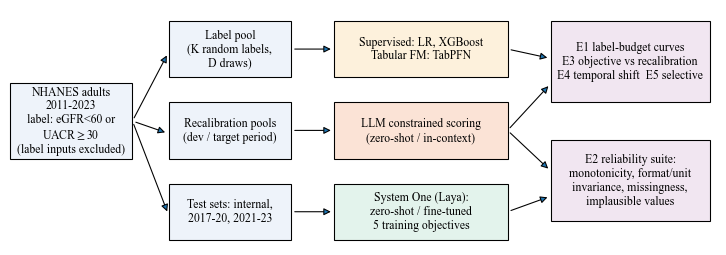

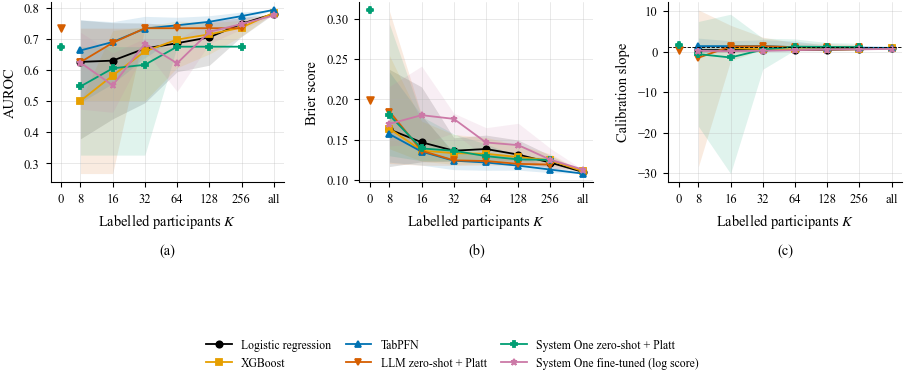

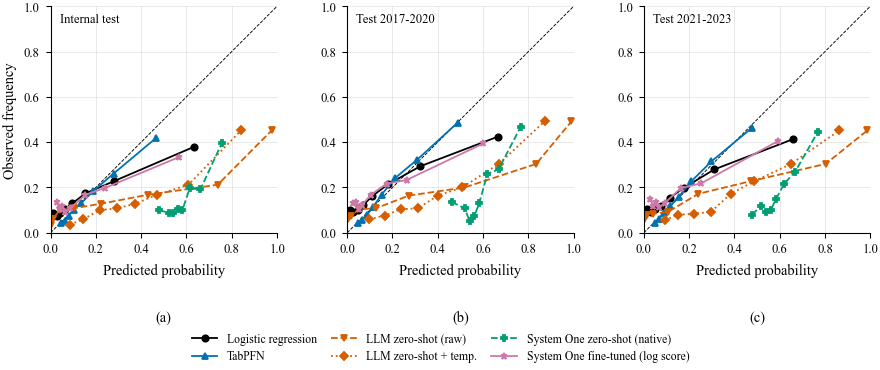

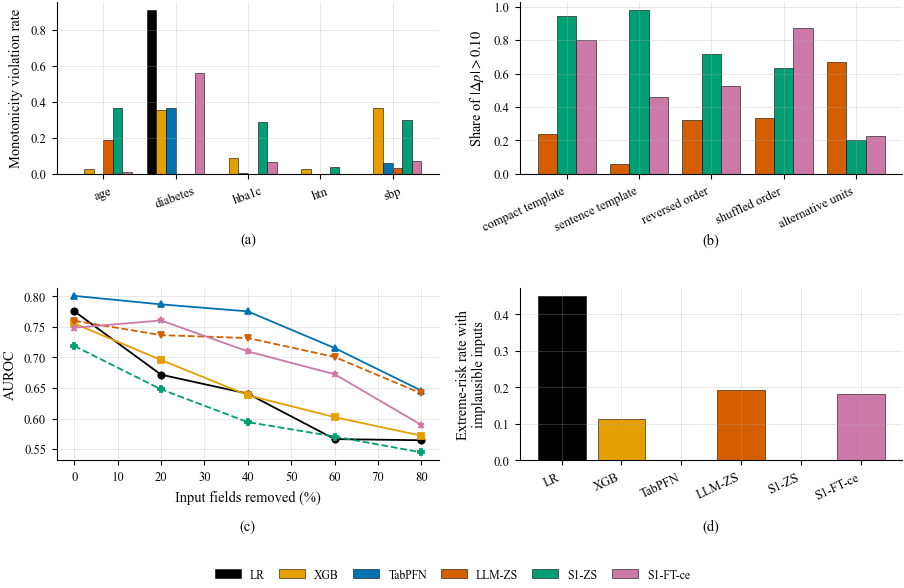

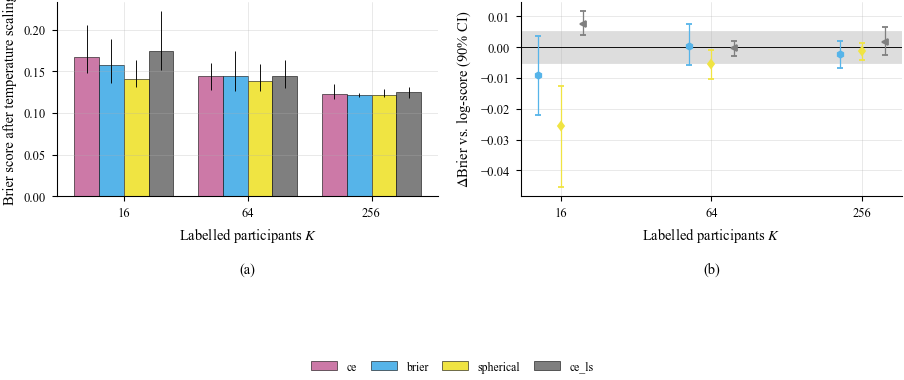

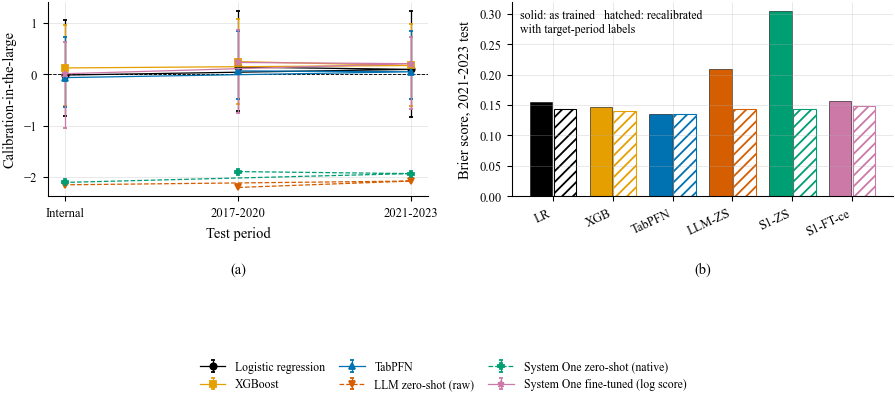

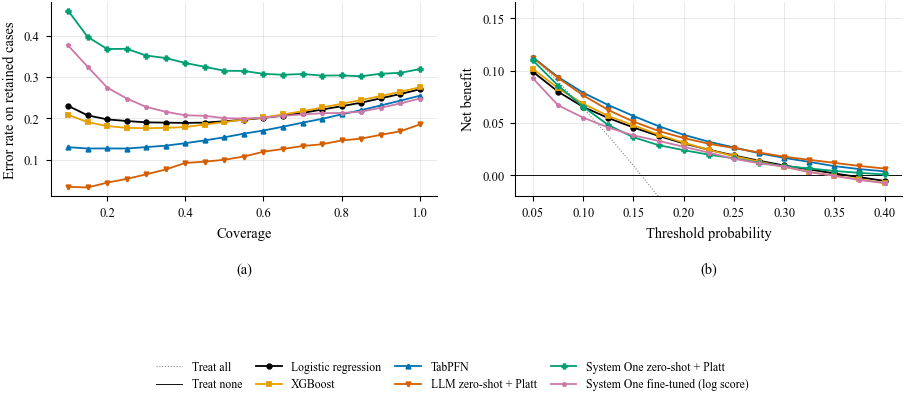

[  54.4 min] Figures: ['fig1_study_design', 'fig2_label_budget', 'fig3_reliability_diagrams', 'fig4_reliability_suite', 'fig5_mechanism_ablation', 'fig6_temporal_shift', 'fig7_selective_decision']
[  54.4 min] Tables written to <project-dir>\ckd_system_one\outputs_laptop8gb\tables


In [11]:
# ============================================================================
# 10. IEEE-STYLE FIGURES AND TABLES  (single column = 3.5 in, double column = 7.16 in; vector PDF + 600-dpi PNG; no in-figure titles)
# ============================================================================
W1, W2 = 3.5, 7.16
OKABE = dict(black="#000000", orange="#E69F00", sky="#56B4E9", green="#009E73", yellow="#F0E442", blue="#0072B2", verm="#D55E00", purple="#CC79A7", grey="#7F7F7F")
STYLE = {"LR": ("black", "o", "-"), "XGB": ("orange", "s", "-"), "TabPFN": ("blue", "^", "-"), "LLM-ZS": ("verm", "v", "--"),
         "LLM-ZS+Platt": ("verm", "v", "-"), "LLM-ZS+TS": ("verm", "D", ":"), "S1-ZS": ("green", "P", "--"), "S1-ZS+Platt": ("green", "P", "-"),
         "S1-ZS+TS": ("green", "X", ":"), "S1-ZS-rawT1": ("grey", "x", "--"), "S1-FT-ce": ("purple", "*", "-"), "S1-FT-brier": ("sky", "h", "-"),
         "S1-FT-spherical": ("yellow", "d", "-"), "S1-FT-ce_ls": ("grey", "<", "-"), "S1-FT-rlcd": ("blue", ">", "--")}
def sty(a): c, m, l = STYLE.get(a, ("grey", "o", "-")); return dict(color=OKABE[c], marker=m, linestyle=l)

def ieee_style():
    plt.rcParams.update({"font.family": "serif", "font.serif": ["Times New Roman", "Times", "STIXGeneral", "DejaVu Serif"], "mathtext.fontset": "stix",
        "font.size": 8, "axes.labelsize": 8, "axes.titlesize": 8, "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 6.5,
        "axes.linewidth": 0.6, "lines.linewidth": 1.0, "lines.markersize": 3.5, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
        "xtick.major.size": 2.5, "ytick.major.size": 2.5, "legend.frameon": False, "axes.grid": True, "grid.linewidth": 0.3, "grid.alpha": 0.5,
        "figure.dpi": 130, "savefig.dpi": 600, "pdf.fonttype": 42, "ps.fonttype": 42, "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
        "axes.spines.top": False, "axes.spines.right": False})
ieee_style()
FIGS = OrderedDict()
def save_fig(fig, name, caption):
    for ext in ("pdf", "png"): fig.savefig(DIRS["figures"] / f"{name}.{ext}")
    FIGS[name] = caption; plt.show(); plt.close(fig)
def panel(ax, lab): ax.text(0.5, -0.34, lab, transform=ax.transAxes, ha="center", va="top", fontsize=8)
def shared_legend(fig, axs, ncol=3, y=-0.02):
    h, l, seen = [], [], set()
    for a in np.ravel(axs):
        for hh, ll in zip(*a.get_legend_handles_labels()):
            if ll not in seen and not ll.startswith("_"): seen.add(ll); h.append(hh); l.append(ll)
        if a.get_legend() is not None: a.get_legend().remove()
    if h: fig.legend(h, l, loc="upper center", bbox_to_anchor=(0.5, y), ncol=ncol, handlelength=2.2, columnspacing=1.2, frameon=False)
def present(arms): return [a for a in arms if a in RUNS]

# ---------------- Fig. 1: study design ----------------
def fig_design():
    fig, ax = plt.subplots(figsize=(W2, 2.5)); ax.axis("off"); ax.set_xlim(0, 100); ax.set_ylim(0, 40)
    def box(x, y, w, h, t, fc="#EEF3FA"): 
        ax.add_patch(plt.Rectangle((x, y), w, h, fc=fc, ec="black", lw=0.6)); ax.text(x + w / 2, y + h / 2, t, ha="center", va="center", fontsize=6.5)
    def arr(x1, y1, x2, y2): ax.annotate("", xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle="-|>", lw=0.6))
    box(1, 15, 17, 12, "NHANES adults\n2011-2023\nlabel: eGFR<60 or\nUACR$\\geq$30\n(label inputs excluded)")
    box(23, 28, 17, 9, "Label pool\n(K random labels,\nD draws)"); box(23, 15, 17, 9, "Recalibration pools\n(dev / target period)"); box(23, 2, 17, 9, "Test sets: internal,\n2017-20, 2021-23")
    box(46, 28, 24, 9, "Supervised: LR, XGBoost\nTabular FM: TabPFN", "#FDF1DC"); box(46, 15, 24, 9, "LLM constrained scoring\n(zero-shot / in-context)", "#FBE3D6"); box(46, 2, 24, 9, "System One (Laya):\nzero-shot / fine-tuned\n5 training objectives", "#E3F3EC")
    box(76, 24, 22, 13, "E1 label-budget curves\nE3 objective vs recalibration\nE4 temporal shift  E5 selective", "#F1E6F1"); box(76, 5, 22, 13, "E2 reliability suite:\nmonotonicity, format/unit\ninvariance, missingness,\nimplausible values", "#F1E6F1")
    arr(18, 21, 23, 32); arr(18, 21, 23, 19); arr(18, 21, 23, 6)
    arr(40, 32.5, 46, 32.5); arr(40, 19.5, 46, 19.5); arr(40, 6.5, 46, 6.5)
    arr(70, 32.5, 76, 31); arr(70, 19.5, 76, 27); arr(70, 19.5, 76, 13); arr(70, 6.5, 76, 9)
    save_fig(fig, "fig1_study_design", "Study design. Every arm receives the same K labelled participants (D random draws) and is evaluated on the same internal and temporally shifted test sets; the reliability suite probes clinical behaviour of the predicted probabilities.")
fig_design()

# ---------------- Fig. 2: label-budget curves ----------------
def fig_label_budget():
    arms = present(["LR", "XGB", "TabPFN", "LLM-ZS+Platt", "S1-ZS+Platt", "S1-FT-ce"]); Ks = sorted({k for a in arms for k in RUNS[a] if k > 0})
    xs = {k: i for i, k in enumerate(Ks)}; fig, axs = plt.subplots(1, 3, figsize=(W2, 2.35))
    for ax, (met, lab) in zip(axs, [("auroc", "AUROC"), ("brier", "Brier score"), ("slope", "Calibration slope")]):
        for a in arms:
            g = RES[(RES.arm == a) & (RES.set == "int") & (RES.K > 0)].groupby("K")[met].apply(lambda x: pd.Series(percentile_ci(x.values), index=["m", "lo", "hi"])).unstack()
            if g.empty: continue
            x = [xs[k] for k in g.index if k in xs]; g = g.loc[[k for k in g.index if k in xs]]
            ax.plot(x, g["m"], label=ARM_LABEL[a], **sty(a)); ax.fill_between(x, g["lo"], g["hi"], color=sty(a)["color"], alpha=0.12, lw=0)
        for a in present(["LLM-ZS", "S1-ZS"]):
            v = RES[(RES.arm == a) & (RES.set == "int") & (RES.K == 0)][met].mean()
            if not np.isnan(v): ax.scatter([-0.6], [v], marker=sty(a)["marker"], color=sty(a)["color"], s=14, zorder=5)
        if met == "slope": ax.axhline(1.0, color="black", lw=0.5, ls="--")
        ax.set_xticks([-0.6] + list(range(len(Ks)))); ax.set_xticklabels(["0"] + [("all" if k == K_FULL else str(k)) for k in Ks]); ax.set_xlabel("Labelled participants $K$"); ax.set_ylabel(lab)
    for ax, l in zip(axs, ["(a)", "(b)", "(c)"]): panel(ax, l)
    fig.tight_layout(w_pad=1.0); shared_legend(fig, axs, ncol=3, y=-0.12)
    save_fig(fig, "fig2_label_budget", "Label-budget curves on the internal test set (mean and 95% interval over random label draws). Markers at $K{=}0$ show zero-shot arms without adaptation. (a) AUROC, (b) Brier score, (c) calibration slope (ideal = 1, dashed).")
fig_label_budget()

# ---------------- Fig. 3: reliability diagrams ----------------
def calib_curve(arm, s, nb=8):
    K = K_TAB if K_TAB in RUNS[arm] else 0
    if K not in RUNS[arm]: return None
    xs, ys = [], []
    for d in RUNS[arm][K]:
        p = load_run(arm, K, d)[SLICE[s]]; y = Y[IDX[s]]; o = np.argsort(p); bins = np.array_split(o, nb)
        xs.append([p[b].mean() for b in bins]); ys.append([y[b].mean() for b in bins])
    return np.mean(xs, 0), np.mean(ys, 0)
def fig_reliability():
    arms = present(["LR", "TabPFN", "LLM-ZS", "LLM-ZS+TS", "S1-ZS", "S1-FT-ce"]); sets = [("int", "Internal test"), ("T1", "Test 2017-2020"), ("T2", "Test 2021-2023")]
    fig, axs = plt.subplots(1, 3, figsize=(W2, 2.5))
    for ax, (s, nm) in zip(axs, sets):
        ax.plot([0, 1], [0, 1], color="black", lw=0.5, ls="--")
        for a in arms:
            c = calib_curve(a, s)
            if c is not None: ax.plot(c[0], c[1], label=ARM_LABEL[a], **sty(a))
        ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_xlabel("Predicted probability"); ax.set_aspect("equal", adjustable="box")
        ax.text(0.04, 0.93, nm, transform=ax.transAxes, fontsize=7)
    axs[0].set_ylabel("Observed frequency")
    for ax, l in zip(axs, ["(a)", "(b)", "(c)"]): panel(ax, l)
    fig.tight_layout(w_pad=0.8); shared_legend(fig, axs, ncol=3, y=-0.02)
    save_fig(fig, "fig3_reliability_diagrams", f"Reliability diagrams (equal-mass bins, averaged over label draws) at $K{{=}}{K_TAB}$ for the internal test set (a) and the two temporally shifted test sets (b), (c). The dashed line is perfect calibration.")
fig_reliability()

# ---------------- Fig. 4: reliability suite ----------------
def fig_suite():
    fig, axs = plt.subplots(2, 2, figsize=(W2, 4.4)); arms = list(REL["mono"].arm.unique())
    ax = axs[0, 0]; feats = list(REL["mono"].feature.unique()); w = 0.8 / max(1, len(arms))
    for i, a in enumerate(arms):
        g = REL["mono"][REL["mono"].arm == a].set_index("feature").reindex(feats)["violation_rate"].values
        ax.bar(np.arange(len(feats)) + i * w, g, w, label=a, color=sty(a)["color"], edgecolor="black", lw=0.3)
    ax.set_xticks(np.arange(len(feats)) + 0.4 - w / 2); ax.set_xticklabels(feats, rotation=20); ax.set_ylabel("Monotonicity violation rate")
    ax = axs[0, 1]; F = REL["fmt"]
    if len(F):
        vs = list(F.variant.unique()); ta = list(F.arm.unique()); w = 0.8 / len(ta)
        for i, a in enumerate(ta):
            g = F[F.arm == a].set_index("variant").reindex(vs)["big_change_rate"].values
            ax.bar(np.arange(len(vs)) + i * w, g, w, label=a, color=sty(a)["color"], edgecolor="black", lw=0.3)
        ax.set_xticks(np.arange(len(vs)) + 0.4 - w / 2); ax.set_xticklabels(vs, rotation=25, ha="right"); ax.set_ylabel("Share of $|\\Delta p|>0.10$")
    ax = axs[1, 0]
    for a in arms:
        g = REL["miss"][REL["miss"].arm == a]; ax.plot(g["rate"] * 100, g["auroc"], label=a, **sty(a))
    ax.set_xlabel("Input fields removed (%)"); ax.set_ylabel("AUROC")
    ax = axs[1, 1]; I = REL["impl"].groupby("arm")["extreme_rate"].mean().reindex(arms)
    ax.bar(np.arange(len(arms)), I.values, color=[sty(a)["color"] for a in arms], edgecolor="black", lw=0.3); ax.set_xticks(np.arange(len(arms))); ax.set_xticklabels(arms, rotation=25, ha="right")
    ax.set_ylabel("Extreme-risk rate with\nimplausible inputs")
    for ax, l in zip(axs.ravel(), ["(a)", "(b)", "(c)", "(d)"]): panel(ax, l)
    fig.tight_layout(h_pad=2.2, w_pad=1.2); shared_legend(fig, axs[0, 0:1].tolist() + [axs[1, 0]], ncol=6, y=0.0)
    save_fig(fig, "fig4_reliability_suite", f"Clinical reliability suite at $K{{=}}{CFG['K_REL']}$. (a) Violations of clinically expected monotonicity (risk should not fall as age, systolic pressure, HbA1c, diabetes or hypertension increase). (b) Share of cases whose predicted risk changes by more than 0.10 under formatting or unit restatement (text arms only; tabular arms are invariant by construction). (c) Discrimination as input fields are removed. (d) Share of predictions that become extreme (<0.02 or >0.98) when an implausible value is injected.")
fig_suite()

# ---------------- Fig. 5: mechanism ablation ----------------
def fig_mech():
    if E3.empty: log("[skip] Fig. 5 (no mechanism-ablation runs)"); return
    fig, axs = plt.subplots(1, 2, figsize=(W2, 2.5)); objs = [o for o in OBJECTIVES if o in set(E3.obj)]; Ks = sorted(E3.K.unique()); w = 0.8 / len(objs)
    ax = axs[0]
    for i, o in enumerate(objs):
        for j, K in enumerate(Ks):
            g = E3[(E3.obj == o) & (E3.K == K) & (E3.recal == "temp")]["brier"].values
            if len(g): mu, lo, hi = percentile_ci(g); ax.bar(j + i * w, mu, w, yerr=[[mu - lo], [hi - mu]], color=sty(f"S1-FT-{o}")["color"], edgecolor="black", lw=0.3, error_kw=dict(lw=0.5), label=o if j == 0 else None)
    ax.set_xticks(np.arange(len(Ks)) + 0.4 - w / 2); ax.set_xticklabels([str(k) for k in Ks]); ax.set_xlabel("Labelled participants $K$"); ax.set_ylabel("Brier score after temperature scaling")
    lo_, hi_ = ax.get_ylim(); ax.set_ylim(max(0, lo_ * 0.9), hi_)
    ax = axs[1]; G = E3P[(E3P.metric == "brier") & (E3P.recal == "temp")]
    ax.axhspan(-EQUIV_MARGIN_BRIER, EQUIV_MARGIN_BRIER, color="#DDDDDD", zorder=0); ax.axhline(0, color="black", lw=0.5)
    for i, o in enumerate([o for o in objs if o != "ce"]):
        for j, K in enumerate(Ks):
            r = G[(G.obj == o) & (G.K == K)]
            if len(r): r = r.iloc[0]; ax.errorbar(j + i * 0.15 - 0.15, r["diff"], yerr=[[r["diff"] - r["lo90"]], [r["hi90"] - r["diff"]]], fmt=sty(f"S1-FT-{o}")["marker"], color=sty(f"S1-FT-{o}")["color"], capsize=1.5, lw=0.7, ms=3.5, label=(o if j == 0 else None))
    ax.set_xticks(range(len(Ks))); ax.set_xticklabels([str(k) for k in Ks]); ax.set_xlabel("Labelled participants $K$"); ax.set_ylabel("$\\Delta$Brier vs. log-score (90% CI)")
    for a_, l in zip(axs, ["(a)", "(b)"]): panel(a_, l)
    fig.tight_layout(w_pad=1.2); shared_legend(fig, axs[0:1], ncol=5, y=-0.12)
    save_fig(fig, "fig5_mechanism_ablation", "Mechanism ablation. (a) Brier score of the same System One backbone fine-tuned with different training objectives, after temperature scaling on a separate calibration set. (b) Paired difference to the log-score (cross-entropy) objective with 90% intervals; the grey band is the pre-registered equivalence margin ($\\pm$0.005).")
fig_mech()

# ---------------- Fig. 6: temporal shift ----------------
def fig_shift():
    arms = present(["LR", "XGB", "TabPFN", "LLM-ZS", "S1-ZS", "S1-FT-ce"]); arms = [a for a in arms if a in set(E4.arm)]
    fig, axs = plt.subplots(1, 2, figsize=(W2, 2.5)); xs = {"int": 0, "T1": 1, "T2": 2}
    ax = axs[0]
    for a in arms:
        g = E4[(E4.arm == a) & (E4.stage == "raw")].groupby("set")["citl"].apply(lambda x: pd.Series(percentile_ci(x.values), index=["m", "lo", "hi"])).unstack()
        if len(g): ax.errorbar([xs[s] for s in g.index], g["m"], yerr=[g["m"] - g["lo"], g["hi"] - g["m"]], capsize=1.2, lw=0.7, label=ARM_LABEL[a], **sty(a))
    ax.axhline(0, color="black", lw=0.5, ls="--"); ax.set_xticks([0, 1, 2]); ax.set_xticklabels(["Internal", "2017-2020", "2021-2023"]); ax.set_xlabel("Test period"); ax.set_ylabel("Calibration-in-the-large")
    ax = axs[1]; w = 0.8 / max(1, len(arms)); T = E4[(E4.set == "T2")]
    for i, a in enumerate(arms):
        r = T[(T.arm == a) & (T.stage == "raw")]["brier"].mean(); c = T[(T.arm == a) & (T.stage == "recal")]["brier"].mean()
        ax.bar(i, r, 0.38, color=sty(a)["color"], edgecolor="black", lw=0.3); ax.bar(i + 0.4, c, 0.38, color="white", edgecolor=sty(a)["color"], hatch="////", lw=0.6)
    ax.set_xticks(np.arange(len(arms)) + 0.2); ax.set_xticklabels(arms, rotation=25, ha="right"); ax.set_ylabel("Brier score, 2021-2023 test")
    ax.text(0.02, 0.96, "solid: as trained   hatched: recalibrated\nwith target-period labels", transform=ax.transAxes, fontsize=6.5, va="top")
    for a_, l in zip(axs, ["(a)", "(b)"]): panel(a_, l)
    fig.tight_layout(w_pad=1.2); shared_legend(fig, axs[0:1], ncol=3, y=-0.12)
    save_fig(fig, "fig6_temporal_shift", f"Temporal shift at $K{{=}}{K_TAB}$. (a) Calibration-in-the-large across test periods (0 = average predicted risk matches observed prevalence). (b) Brier score on the 2021-2023 test set before and after recalibration with a small labelled sample from the target period.")
fig_shift()

# ---------------- Fig. 7: selective prediction and decision curves ----------------
def fig_sel_dca():
    arms = present(["LR", "XGB", "TabPFN", "LLM-ZS+Platt", "S1-ZS+Platt", "S1-FT-ce"]); fig, axs = plt.subplots(1, 2, figsize=(W2, 2.5))
    ax = axs[0]
    for a in arms:
        if a in RC: c, r = RC[a]; ax.plot(c, r.mean(0), label=ARM_LABEL[a], **{**sty(a), "markersize": 2.5})
    ax.set_xlabel("Coverage"); ax.set_ylabel("Error rate on retained cases")
    ax = axs[1]; prev = Y[IDX["int"]].mean(); ax.plot(THR, [prev - (1 - prev) * t / (1 - t) for t in THR], color="grey", lw=0.6, ls=":", label="Treat all"); ax.axhline(0, color="black", lw=0.5, label="Treat none")
    for a in arms:
        if a in DCA: ax.plot(THR, DCA[a].mean(0), label=ARM_LABEL[a], **{**sty(a), "markersize": 2.5})
    ax.set_ylim(-0.02, prev * 1.05); ax.set_xlabel("Threshold probability"); ax.set_ylabel("Net benefit")
    for a_, l in zip(axs, ["(a)", "(b)"]): panel(a_, l)
    fig.tight_layout(w_pad=1.2); shared_legend(fig, axs[1:2], ncol=4, y=-0.12)
    save_fig(fig, "fig7_selective_decision", f"(a) Risk--coverage curves: error rate when only the most confident fraction of cases is decided automatically (threshold fixed on a validation split). (b) Decision-curve net benefit on the internal test set at $K{{=}}{K_TAB}$.")
fig_sel_dca()

# ============================ TABLES (LaTeX, IEEEtran style) ============================
def tex_escape(s): return str(s).replace("_", "\\_").replace("%", "\\%").replace("&", "\\&").replace("#", "\\#")
def fmt(x, nd=3):
    return "--" if x is None or (isinstance(x, float) and np.isnan(x)) else (f"{x:.{nd}f}" if isinstance(x, (float, np.floating)) else str(x))
def ci(r, m, nd=3): return f"{fmt(r[m], nd)} ({fmt(r[m + '_lo'], nd)}--{fmt(r[m + '_hi'], nd)})"
def write_table(name, caption, header, rows, colfmt=None):
    colfmt = colfmt or "l" + "c" * (len(header) - 1)
    L = ["\\begin{table}[!t]", f"\\caption{{{caption}}}", f"\\label{{tab:{name}}}", "\\centering", "\\footnotesize", f"\\begin{{tabular}}{{{colfmt}}}", "\\hline"]
    L.append(" & ".join(tex_escape(h) for h in header) + " \\\\ \\hline")
    for r in rows: L.append(" & ".join(tex_escape(c) for c in r) + " \\\\")
    L += ["\\hline", "\\end{tabular}", "\\end{table}"]; (DIRS["tables"] / f"{name}.tex").write_text("\n".join(L))
    pd.DataFrame(rows, columns=header).to_csv(DIRS["tables"] / f"{name}.csv", index=False); return pd.DataFrame(rows, columns=header)

# Table I cohort
rows = []
for nm, d_ in [("2011--2016 (development)", dev), ("2017--2020 (test)", t1), ("2021--2023 (test)", t2)]:
    rows.append([nm, f"{len(d_):,}", f"{d_['age'].mean():.1f}", f"{100*d_['sex_female'].mean():.1f}", f"{100*d_['y'].mean():.1f}", f"{d_['sbp'].mean():.1f}", f"{d_['hba1c'].mean():.2f}", f"{100*d_['diabetes'].mean():.1f}"])
TAB1 = write_table("cohort", "Characteristics of the NHANES adult cohorts (unweighted).", ["Period", "$n$", "Age (y)", "Female (\\%)", "CKD-range (\\%)", "SBP (mmHg)", "HbA1c (\\%)", "Diabetes (\\%)"], rows)
# Table II main results
for s in ["int", "T2"]:
    rows = [[ARM_LABEL[r["arm"]], str(r["K"]), ci(r, "auroc"), ci(r, "brier"), ci(r, "ece"), ci(r, "slope", 2)] for _, r in MAIN[MAIN.set == s].iterrows()]
    write_table(f"main_{s}", f"Performance at the headline label budget ($K{{=}}{K_TAB}$; zero-shot rows $K{{=}}0$), {'internal' if s=='int' else '2021--2023'} test set, mean (95\\% interval over label draws).",
                ["Model", "$K$", "AUROC", "Brier", "ECE", "Cal. slope"], rows, "lccccc")
# Table III reliability summary
rows = []
for a in REL["mono"].arm.unique():
    mono = REL["mono"][REL["mono"].arm == a]["violation_rate"].mean(); fm = REL["fmt"][REL["fmt"].arm == a]["big_change_rate"].mean() if len(REL["fmt"]) else np.nan
    ms = REL["miss"][REL["miss"].arm == a].sort_values("rate"); drop = ms["auroc"].iloc[0] - ms["auroc"].iloc[-1]; ex = REL["impl"][REL["impl"].arm == a]["extreme_rate"].mean()
    rows.append([a, fmt(mono), fmt(fm), fmt(drop), fmt(ex)])
TAB3 = write_table("reliability", "Reliability-suite summary: mean monotonicity-violation rate, share of large changes under restatement, AUROC loss at the highest missingness rate, and extreme-risk rate with implausible inputs.", ["Model", "Monot. viol.", "Restatement", "AUROC drop", "Extreme rate"], rows)
# Table IV mechanism ablation
rows = [[r["obj"], str(int(r["K"])), r["recal"], fmt(r["diff"], 4), f"{fmt(r['lo95'],4)}--{fmt(r['hi95'],4)}", "yes" if r["equivalent"] is True else ("no" if r["equivalent"] is False else "--")] for _, r in E3P[E3P.metric == "brier"].iterrows()] if len(E3P) else []
TAB4 = write_table("mechanism", "Mechanism ablation: paired $\\Delta$Brier of each objective relative to the log-score objective (equivalence = 90\\% interval within $\\pm$0.005).", ["Objective", "$K$", "Recal.", "$\\Delta$Brier", "95\\% CI", "Equiv."], rows)
# Table V paired comparisons
rows = [[ARM_LABEL[r["arm"]], r["set"], r["metric"], fmt(r["diff"], 4), f"{fmt(r['lo'],4)}--{fmt(r['hi'],4)}", f"{r['p_holm']:.3f}"] for _, r in PAIR.iterrows()] if len(PAIR) else []
TAB5 = write_table("paired", f"Paired differences versus {REF} at $K{{=}}{K_TAB}$ (bootstrap 95\\% CI; Holm-adjusted $p$).", ["Model", "Set", "Metric", "Diff.", "95\\% CI", "$p_{\\mathrm{Holm}}$"], rows)
# Table VI compute
rows = [[k, f"{v/60:.1f}"] for k, v in TIMER.t.items()]
TAB6 = write_table("compute", "Wall-clock time per component (minutes) on the run hardware.", ["Component", "Minutes"], rows)
# captions
with open(DIRS["figures"] / "figure_captions.md", "w") as f:
    for i, (k, v) in enumerate(FIGS.items(), 1): f.write(f"**Fig. {i}.** {v}\n\n")
log("Figures:", list(FIGS)); log("Tables written to", DIRS["tables"])

## 11. Manifest, verdicts and export

In [12]:
# ============================================================================
# 11. REPRODUCIBILITY MANIFEST, HYPOTHESIS SUMMARY, ZIP OF ALL OUTPUTS
# ============================================================================
def sha(p):
    h = hashlib.sha256()
    with open(p, "rb") as f:
        for ch in iter(lambda: f.read(1 << 20), b""): h.update(ch)
    return h.hexdigest()[:16]
def ver(m):
    try: return __import__(m).__version__
    except Exception: return None
MAN = dict(created=datetime.now(timezone.utc).isoformat(), profile=PROFILE, seed=PRIMARY_SEED, python=platform.python_version(), platform=platform.platform(),
           packages={m: ver(m) for m in ["numpy", "pandas", "scipy", "sklearn", "xgboost", "torch", "transformers", "peft", "tabpfn", "laya", "matplotlib"]},
           gpu=(torch.cuda.get_device_name(0) if HAS_TORCH and torch.cuda.is_available() else None),
           models=dict(llm=globals().get("LLM_ID"), laya=(BASE.ident if BASE is not None else None), tabpfn=str(TABPFN_STATE.get("version"))),
           config={k: v for k, v in CFG.items() if k != "HF_TOKEN"}, equivalence_margin_brier=EQUIV_MARGIN_BRIER,
           hypotheses=HYPOTHESES, verdicts=VERD, split_sizes={s: int(len(IDX[s])) for s in IDX},
           data_files={p.name: sha(p) for p in sorted(DATA_RAW.glob("*.xpt"))}, arms=sorted(RUNS), runtime_minutes=round((time.time() - T0) / 60, 1),
           timers_seconds={k: round(v, 1) for k, v in TIMER.t.items()}, laya_consistency_error=LAYA_CHECK)
(DIRS["logs"] / "manifest.json").write_text(json.dumps(MAN, indent=1, default=str))
print(json.dumps({k: MAN[k] for k in ["profile", "models", "split_sizes", "runtime_minutes"]}, indent=1, default=str))
print("\nHYPOTHESIS CHECKS (mechanical, pre-specified rules; interpret with the full tables):")
for h, v in VERD.items(): print(f"  {h}: {HYPOTHESES[h][:90]}...\n      -> {v}")
if PROFILE == "smoke": print("\n*** SMOKE profile used synthetic data and random stand-in models: these numbers are meaningless; do not report them. ***")
import shutil
zip_path = shutil.make_archive(str(ROOT / f"results_{PROFILE}"), "zip", OUT); print("\nAll outputs zipped:", zip_path)
if IN_COLAB:
    try:
        from google.colab import files; files.download(zip_path)
    except Exception: pass

{
 "profile": "laptop8gb",
 "models": {
  "llm": "Qwen/Qwen3-4B-Instruct-2507",
  "laya": "convaiinnovations/laya",
  "tabpfn": "ModelVersion.V3_5"
 },
 "split_sizes": {
  "pool": 3000,
  "val": 1000,
  "int": 2000,
  "T1pool": 1000,
  "T1": 2000,
  "T2pool": 1000,
  "T2": 2000
 },
 "runtime_minutes": 54.4
}

HYPOTHESIS CHECKS (mechanical, pre-specified rules; interpret with the full tables):
  H1: After recalibration with >=64 labels, proper-score-trained and cross-entropy-trained Syste...
      -> not supported (equivalent in 1/4 proper-score comparisons after temperature scaling)
  H2: Text-serialized decision models violate clinical monotonicity and flip under formatting/un...
      -> not supported (mean monotonicity violation text arms 0.128 vs reference 0.134; mean big-change rate under restatement 0.532)
  H3: TabPFN matches or beats every System One / LLM arm on AUROC at >=16 labels (null-favouring...
      -> not supported (arms exceeding TabPFN mean AUROC: [('LLM-ZS+Platt', 